# Health Risk Prediction Using Machine Learning Across Heterogeneous Patient Populations

---

**Course Code:** CS4082 Machine Learning

**Institution:** Effat University, Computer Science Department

**Students' Names:** Ghala Alghamdi, Hiba Amanulla, Hams Aljohani

**Students' IDs:** S23108212, S23108227, S20106833

**Instructor:** Dr. Naila Marir

---

## Project Overview

This project focuses on predicting health risk using machine learning techniques applied to ICU (Intensive Care Unit) data from the eICU Collaborative Research Database. The main objective is to develop models that can predict patient outcomes, specifically hospital mortality, based on clinical and demographic information.

The dataset contains patient records collected from multiple hospitals, including features such as vital signs, laboratory measurements, and severity scores. This makes it suitable for studying health risk prediction in real-world settings.

A key aspect of this project is the analysis of heterogeneous patient populations. Since the data comes from different hospitals and patient groups, there may be variations in data distribution. These differences can affect model performance and generalization. Therefore, this project also examines how well machine learning models perform across diverse patient populations.

The project follows a structured machine learning pipeline, including problem definition, data collection, preprocessing, feature engineering, model training, and evaluation. The final goal is to identify models that provide accurate and reliable predictions while maintaining robustness across different subsets of the data.

---

## Stage 1: Problem Definition


### 1.1 Problem
The goal of this project is to predict patient health risk using ICU data.


### 1.2 Research Question
Can machine learning models predict hospital mortality using ICU patient data, and how well do they generalize across heterogeneous patient populations?


### 1.3 ML Task Type
This is a supervised binary classification problem.



### 1.4 Target Variable
The target variable is hospital discharge status:
- 0 = Alive
- 1 = Expired



### 1.5 Success Metrics
The main evaluation metrics will be:
- AUROC
- Accuracy
- Precision
- Recall
- F1-score

AUROC is especially important because healthcare datasets may be imbalanced.




---




## Stage 2: Data Collection


### 2.1 Identify Data Sources

In this stage, the dataset is selected and loaded for analysis. The eICU Collaborative Research Database (Demo Version 2.0) is used, which contains ICU patient records collected from multiple hospitals.

Instead of using all available files, a subset of relevant tables is selected to simplify the analysis and focus on important clinical features for mortality prediction. The selected files include:

- `patient.csv`: Contains patient demographics and discharge status (used to define the target variable)
- `apachePatientResult.csv`: Contains severity scores and outcome-related information
- `apachePredVar.csv`: Includes predicted clinical variables
- `apacheApsVar.csv`: Contains physiological measurements

These files are chosen because they provide structured and meaningful features that are directly related to patient health risk. The datasets are then loaded and inspected to ensure they are correctly read and ready for preprocessing.

### 2.2 Collect Relevant Data

#### 2.2.1 Import libraries

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report



from xgboost import XGBClassifier

#### 2.2.2 Read Data

In [72]:
patient = pd.read_csv("patient.csv")
apache_patient_result = pd.read_csv("apachePatientResult.csv")
apache_pred_var = pd.read_csv("apachePredVar.csv")
apache_aps_var = pd.read_csv("apacheApsVar.csv")

### 2.3 Ensure data quality and quantity

In this step, the datasets are explored to understand their structure, including the number of rows and columns, feature names, and sample records. This helps identify useful variables, potential target columns, and any inconsistencies before preprocessing.

#### 2.3.1 Verify Data Structure and Completeness

In [73]:
#check Shape + Columns

datasets = {
    "patient": patient,
    "apache_patient_result": apache_patient_result,
    "apache_pred_var": apache_pred_var,
    "apache_aps_var": apache_aps_var
}

for name, df in datasets.items():
    print("=" * 60)
    print(name.upper())
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print()

PATIENT
Shape: (2520, 29)

Columns:
['patientunitstayid', 'patienthealthsystemstayid', 'gender', 'age', 'ethnicity', 'hospitalid', 'wardid', 'apacheadmissiondx', 'admissionheight', 'hospitaladmittime24', 'hospitaladmitoffset', 'hospitaladmitsource', 'hospitaldischargeyear', 'hospitaldischargetime24', 'hospitaldischargeoffset', 'hospitaldischargelocation', 'hospitaldischargestatus', 'unittype', 'unitadmittime24', 'unitadmitsource', 'unitvisitnumber', 'unitstaytype', 'admissionweight', 'dischargeweight', 'unitdischargetime24', 'unitdischargeoffset', 'unitdischargelocation', 'unitdischargestatus', 'uniquepid']

APACHE_PATIENT_RESULT
Shape: (3676, 23)

Columns:
['apachepatientresultsid', 'patientunitstayid', 'physicianspeciality', 'physicianinterventioncategory', 'acutephysiologyscore', 'apachescore', 'apacheversion', 'predictedicumortality', 'actualicumortality', 'predictediculos', 'actualiculos', 'predictedhospitalmortality', 'actualhospitalmortality', 'predictedhospitallos', 'actualhosp

#### 2.3.2 Inspect Sample Records

In [74]:
#view first few rows of each dataset

for name, df in datasets.items():
    print("=" * 60)
    print(name.upper(), "- First 5 Rows")
    display(df.head())

PATIENT - First 5 Rows


,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,unitadmitsource,unitvisitnumber,unitstaytype,admissionweight,dischargeweight,unitdischargetime24,unitdischargeoffset,unitdischargelocation,unitdischargestatus,uniquepid
0,141764,129391,Female,87,Caucasian,59,91,NaN,157.5,23:36:00,...,ICU to SDU,2,stepdown/other,NaN,NaN,18:58:00,344,Home,Alive,002-1039
1,141765,129391,Female,87,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",157.5,23:36:00,...,Emergency Department,1,admit,46.5,45.0,13:14:00,2250,Step-Down Unit (SDU),Alive,002-1039
2,143870,131022,Male,76,Caucasian,68,103,"Endarterectomy, carotid",167.0,20:46:00,...,Operating Room,1,admit,77.5,79.4,10:00:00,793,Floor,Alive,002-12289
3,144815,131736,Female,34,Caucasian,56,82,"Overdose, other toxin, poison or drug",172.7,01:44:00,...,Emergency Department,1,admit,60.3,60.7,20:48:00,1121,Other External,Alive,002-1116
4,145427,132209,Male,61,Caucasian,68,103,"GI perforation/rupture, surgery for",177.8,23:48:00,...,Operating Room,1,admit,91.7,93.1,22:47:00,1369,Floor,Alive,002-12243


APACHE_PATIENT_RESULT - First 5 Rows


,apachepatientresultsid,patientunitstayid,physicianspeciality,physicianinterventioncategory,acutephysiologyscore,apachescore,apacheversion,predictedicumortality,actualicumortality,predictediculos,...,predictedhospitallos,actualhospitallos,preopmi,preopcardiaccath,ptcawithin24h,unabridgedunitlos,unabridgedhosplos,actualventdays,predventdays,unabridgedactualventdays
0,31917,141765,hospitalist,Unknown,23,47,IV,0.008247,ALIVE,0.722231,...,2.881710,1.8222,0,0,0,1.5625,1.8222,NaN,NaN,NaN
1,31918,141765,hospitalist,Unknown,23,47,IVa,0.012311,ALIVE,1.374807,...,3.173925,1.8222,0,0,0,1.5625,1.8222,NaN,NaN,NaN
2,21398,143870,family practice,Unknown,43,60,IVa,0.015707,ALIVE,3.021671,...,6.032627,0.8465,0,0,0,0.5506,0.8465,NaN,NaN,NaN
3,21397,143870,family practice,Unknown,43,60,IV,0.017739,ALIVE,3.006522,...,5.955292,0.8465,0,0,0,0.5506,0.8465,NaN,NaN,NaN
4,181,144815,internal medicine,I,25,25,IV,0.001834,ALIVE,0.592446,...,2.196294,0.8063,0,0,0,0.7784,0.8063,NaN,NaN,NaN


APACHE_PRED_VAR - First 5 Rows


,apachepredvarid,patientunitstayid,sicuday,saps3day1,saps3today,saps3yesterday,gender,teachtype,region,bedcount,...,creatinine,dischargelocation,visitnumber,amilocation,day1meds,day1verbal,day1motor,day1eyes,day1pao2,day1fio2
0,4004,141765,1,0,0,0,1,0,3,12,...,1.04,4,1,-1,0,5,6,4,-1.0,-1
1,8047,143870,1,0,0,0,0,0,3,14,...,1.14,4,1,-1,0,5,6,4,-1.0,-1
2,1798882,144815,1,0,0,0,1,0,3,8,...,0.63,8,1,-1,0,5,6,4,-1.0,-1
3,1485310,145427,1,0,0,0,0,0,3,14,...,1.05,4,1,-1,0,5,6,4,-1.0,-1
4,27991,147307,1,0,0,0,1,0,3,43,...,-1.00,4,1,-1,0,5,6,4,-1.0,-1


APACHE_APS_VAR - First 5 Rows


,apacheapsvarid,patientunitstayid,intubated,vent,dialysis,eyes,motor,verbal,meds,urine,...,ph,hematocrit,creatinine,albumin,pao2,pco2,bun,glucose,bilirubin,fio2
0,92788,141765,0,0,0,4,6,5,0,-1.0,...,-1.0,37.8,1.04,-1.0,-1.0,-1.0,28.0,61,-1.0,-1
1,8893,143870,0,0,0,4,6,5,0,-1.0,...,-1.0,34.1,1.14,-1.0,-1.0,-1.0,14.0,140,-1.0,-1
2,79585,144815,0,0,0,4,6,5,0,-1.0,...,-1.0,36.6,0.63,3.6,-1.0,-1.0,6.0,82,0.5,-1
3,203242,145427,0,0,0,4,6,5,0,-1.0,...,-1.0,40.4,1.05,-1.0,-1.0,-1.0,14.0,118,-1.0,-1
4,154681,147307,0,0,0,4,6,5,0,-1.0,...,-1.0,-1.0,-1.00,-1.0,-1.0,-1.0,-1.0,-1,-1.0,-1


#### 2.3.3 Identify Target-Related Information

In [75]:
#check possible target-related columns in patient table

target_cols = [col for col in patient.columns if "discharge" in col.lower() or "status" in col.lower()]
print("Possible target columns:")
print(target_cols)

display(patient[target_cols].head())

Possible target columns:
['hospitaldischargeyear', 'hospitaldischargetime24', 'hospitaldischargeoffset', 'hospitaldischargelocation', 'hospitaldischargestatus', 'dischargeweight', 'unitdischargetime24', 'unitdischargeoffset', 'unitdischargelocation', 'unitdischargestatus']


,hospitaldischargeyear,hospitaldischargetime24,hospitaldischargeoffset,hospitaldischargelocation,hospitaldischargestatus,dischargeweight,unitdischargetime24,unitdischargeoffset,unitdischargelocation,unitdischargestatus
0,2015,19:20:00,366,Home,Alive,NaN,18:58:00,344,Home,Alive
1,2015,19:20:00,2616,Home,Alive,45.0,13:14:00,2250,Step-Down Unit (SDU),Alive
2,2014,17:05:00,1218,Home,Alive,79.4,10:00:00,793,Floor,Alive
3,2015,21:05:00,1138,Other Hospital,Alive,60.7,20:48:00,1121,Other External,Alive
4,2014,15:41:00,5263,Home,Alive,93.1,22:47:00,1369,Floor,Alive


**Inspection Summary**

The datasets contain a large number of clinical and demographic features relevant to patient health and ICU outcomes. The `patient` table includes important variables such as age, gender, and hospital discharge status, which is used to define the target variable for mortality prediction.

From the inspection, the column `hospitaldischargestatus` was identified as the most suitable target variable, as it indicates whether a patient survived or expired.

All selected tables share the common identifier `patientunitstayid`, which will be used to merge the datasets in the preprocessing stage. The data appears well-structured and consistent across tables, although some missing values and duplicate information may be present and will need to be handled in the next stage.

Overall, the dataset is suitable for machine learning, particularly for studying health risk prediction across heterogeneous patient populations.


### 2.4 Ethical and Data Considerations

The dataset consists of anonymized ICU patient records from the eICU database. No personally identifiable information is included, ensuring patient privacy. The data is used for research and educational purposes only, following ethical guidelines for handling healthcare data.





---

## Stage 3: Data Preparation (Preprocessing)

In this stage, the datasets are prepared for machine learning. This includes creating the target variable, selecting relevant features, merging multiple tables, and handling missing values.

The goal is to transform the raw data into a clean and structured format that can be used for model training.

### 3.1 Exploratory Data Analysis (EDA)

In this step, the dataset is explored to better understand its structure, distribution, and potential quality issues before preprocessing. Exploratory Data Analysis (EDA) helps identify important patterns in the data and supports later preprocessing decisions.

The analysis focuses on:
- class distribution of the target variable
- missing values across features
- outliers in numerical variables
- correlations between features

Visualizations such as histograms, boxplots, and heatmaps are used to better understand the data and guide the preprocessing stage.

#### 3.1.1 Class Distribution

To analyze the class distribution, the target variable (target_mortality) was first derived from the `hospitaldischargestatus` column, where:
- 0 = survived  
- 1 = expired  

The class distribution is examined to understand the balance between patients who survived and those who expired. This is important because imbalanced classes can affect model performance and make some evaluation metrics misleading.

,hospitaldischargestatus,target_mortality
0,Alive,0
1,Alive,0
2,Alive,0
3,Alive,0
4,Alive,0


Counts:
target_mortality
0    2308
1     212
Name: count, dtype: int64

Percentages:
target_mortality
0    91.59
1     8.41
Name: proportion, dtype: float64


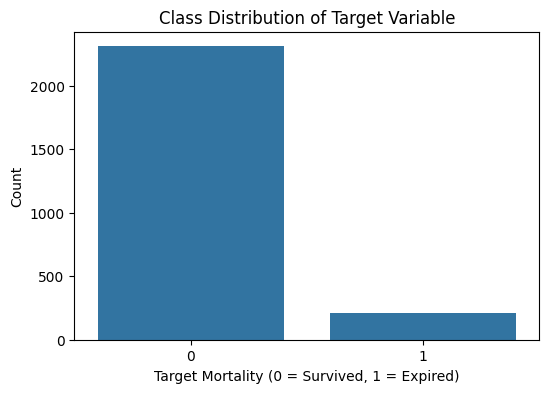

In [115]:
#create Target Variable

patient["target_mortality"] = patient["hospitaldischargestatus"].apply(
    lambda x: 1 if str(x).strip().lower() == "expired" else 0
)

display(patient[["hospitaldischargestatus", "target_mortality"]].head())

plt.style.use("default")

#print counts
print("Counts:")
print(patient["target_mortality"].value_counts())

print("\nPercentages:")
print((patient["target_mortality"].value_counts(normalize=True) * 100).round(2))

#visualize class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=patient["target_mortality"])
plt.title("Class Distribution of Target Variable")
plt.xlabel("Target Mortality (0 = Survived, 1 = Expired)")
plt.ylabel("Count")
plt.show()

**Class Distribution Summary**

The target variable shows a clear class imbalance, with approximately 91.6% of patients surviving and 8.4% deceased.

This imbalance is important because it can affect model performance. In such cases, accuracy alone may be misleading, so evaluation metrics such as precision, recall, F1-score, and AUROC will be used in later stages.

#### 3.1.2 Missing Values

Missing values are analyzed to identify incomplete features and assess their impact on the dataset. This helps determine which columns should be retained, removed, or imputed during preprocessing.

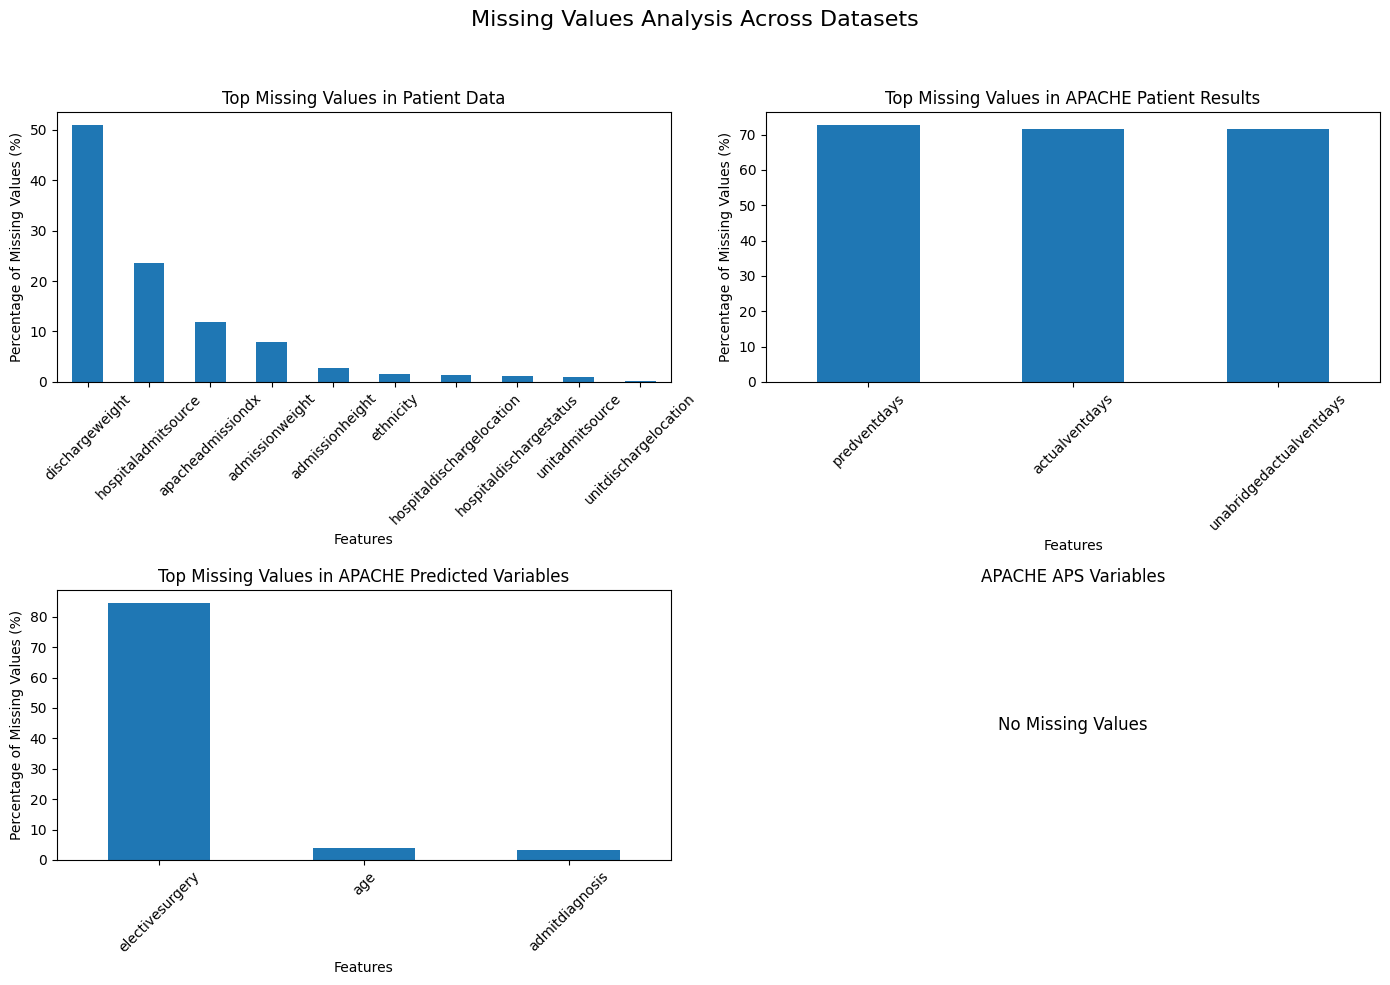

In [116]:
plt.style.use("default")

datasets = {
    "Patient Data": patient,
    "APACHE Patient Results": apache_patient_result,
    "APACHE Predicted Variables": apache_pred_var,
    "APACHE APS Variables": apache_aps_var
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, df) in enumerate(datasets.items()):

    ax = axes[i]

    # calculate missing %
    missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)
    missing_percent = missing_percent[missing_percent > 0]

    if len(missing_percent) > 0:
        missing_percent.head(10).plot(
            kind="bar",
            ax=ax,
        )

        ax.set_title(f"Top Missing Values in {name}")
        ax.set_ylabel("Percentage of Missing Values (%)")
        ax.set_xlabel("Features")
        ax.tick_params(axis='x', rotation=45)

    else:
        ax.text(
            0.5, 0.5,
            "No Missing Values",
            ha='center', va='center',
            fontsize=12
        )
        ax.set_title(f"{name}")
        ax.axis("off")

# MAIN TITLE
plt.suptitle("Missing Values Analysis Across Datasets", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Missing Values Summary**

The missing value analysis shows that the level of missing data varies across datasets. The patient dataset has moderate missing values in some features, while the APACHE predicted variables contain very high missing percentages for certain columns.

In contrast, the APACHE APS variables dataset contains no missing values. These findings indicate that different preprocessing strategies will be required, including dropping highly incomplete features and imputing the remaining missing values.

#### 3.1.3 Numerical Features

Histograms are used to examine the distribution of numerical variables. This helps identify patterns such as skewness, concentration of values, and potential outliers.

Understanding these distributions is important for later preprocessing steps such as scaling and transformation.

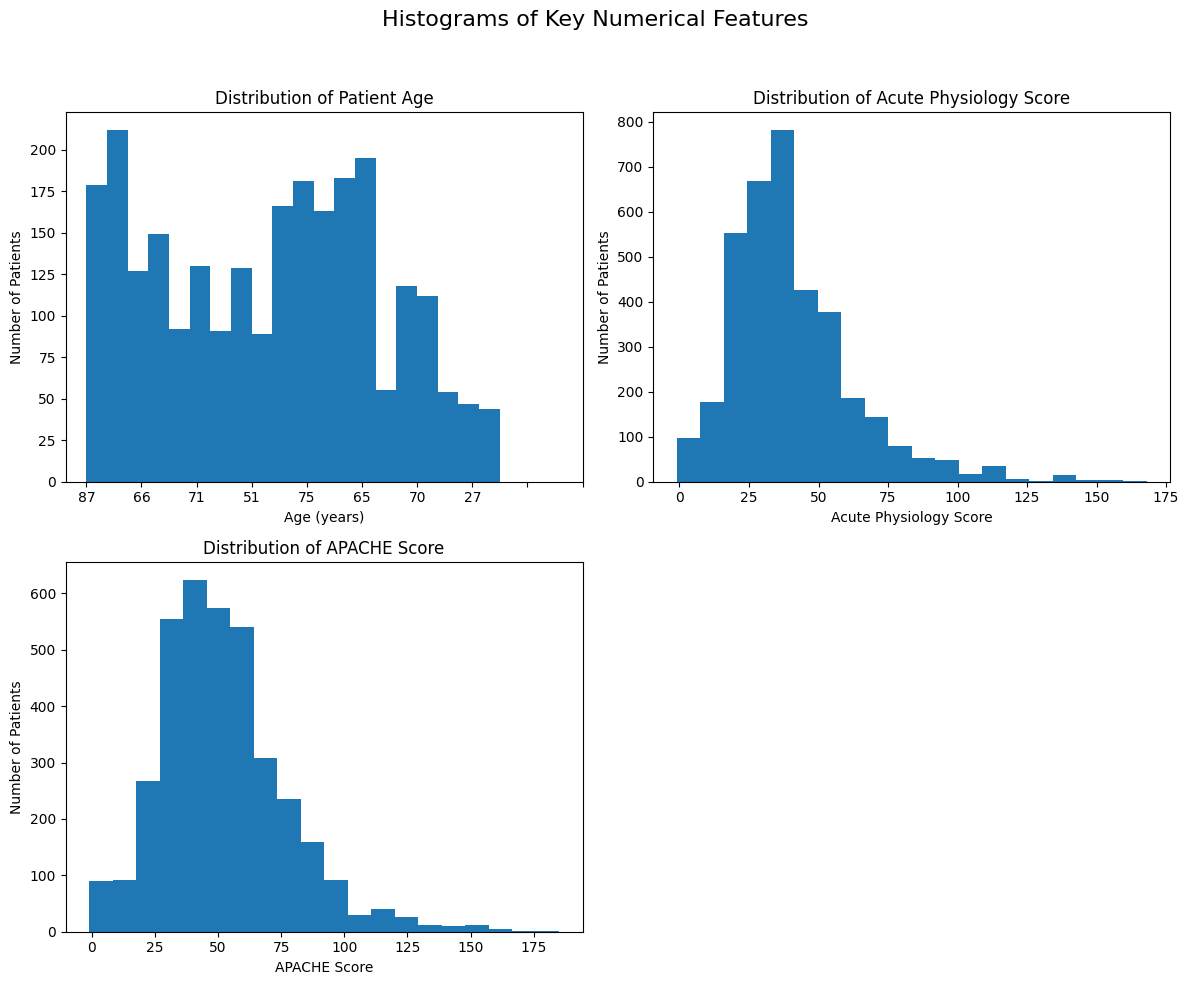

In [117]:
plt.style.use("default")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# AGE
axes[0].hist(patient["age"].dropna(), bins=20)
axes[0].set_title("Distribution of Patient Age")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Number of Patients")
axes[0].set_xticks(range(0, 100, 10))

# APACHE FEATURES (FIX HERE)
apache_cols = ["acutephysiologyscore", "apachescore"]
available_cols = [col for col in apache_cols if col in apache_patient_result.columns]

for i, col in enumerate(available_cols):
    axes[i+1].hist(apache_patient_result[col].dropna(), bins=20)

    if col == "acutephysiologyscore":
        axes[i+1].set_title("Distribution of Acute Physiology Score")
        axes[i+1].set_xlabel("Acute Physiology Score")

    elif col == "apachescore":
        axes[i+1].set_title("Distribution of APACHE Score")
        axes[i+1].set_xlabel("APACHE Score")

    axes[i+1].set_ylabel("Number of Patients")

# REMOVE EMPTY PLOTS
for j in range(len(available_cols) + 1, len(axes)):
    fig.delaxes(axes[j])

# MAIN TITLE
plt.suptitle("Histograms of Key Numerical Features", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Numerical Features Summary**

The histograms show the distribution of key numerical features. Patient age appears relatively spread out, while the acute physiology score and APACHE score are right-skewed, with most values concentrated in lower ranges.

This indicates that extreme values exist but are less common. Understanding these distributions is important for later preprocessing steps such as scaling and handling skewness.

#### 3.1.4 Outlier Detection

Boxplots are used to detect outliers in numerical variables. Outliers may represent extreme but valid medical conditions or potential data noise.

Identifying outliers helps determine whether special preprocessing or transformations are needed.

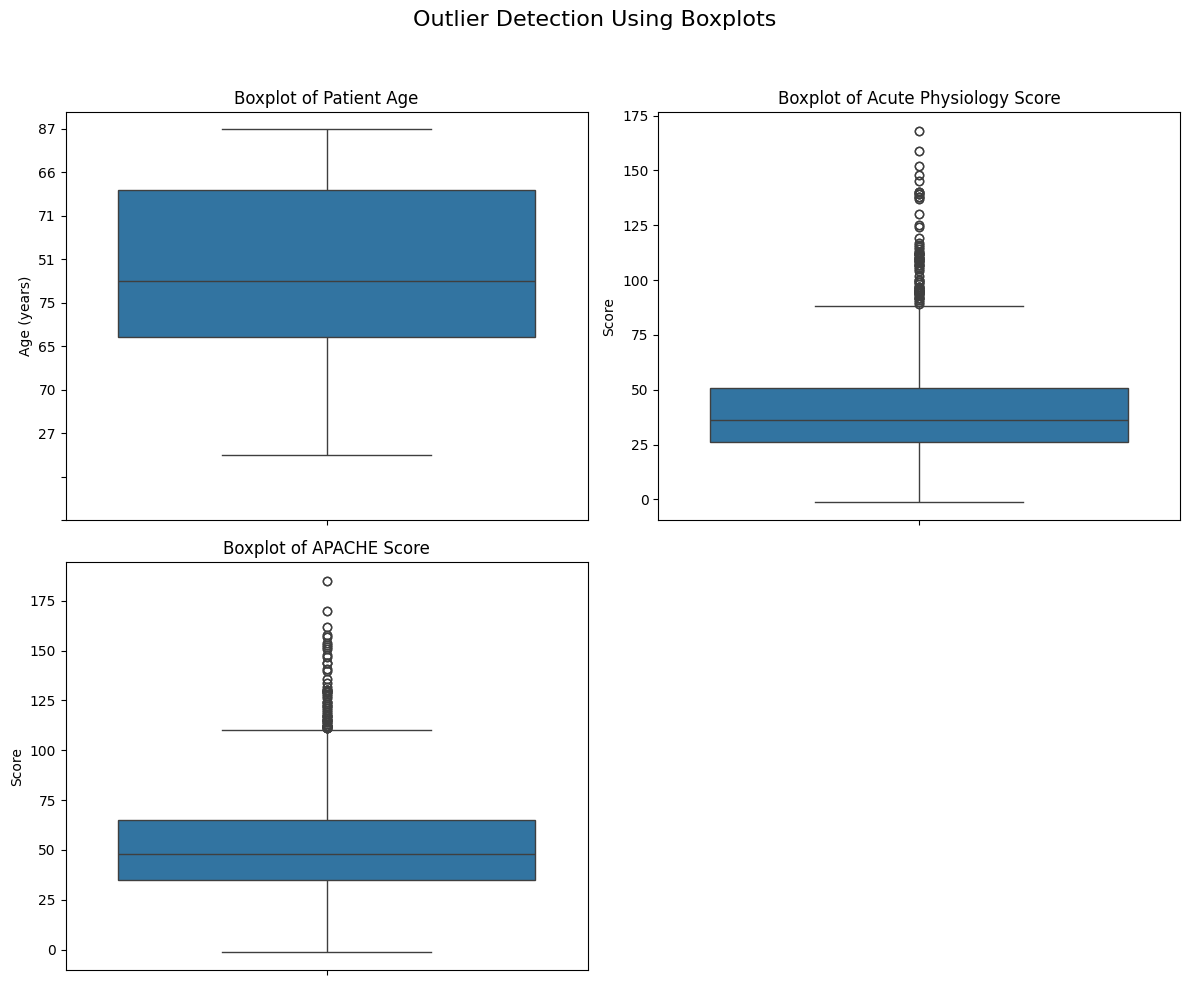

In [118]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

#AGE
sns.boxplot(y=patient["age"], ax=axes[0], color="#1f77b4")
axes[0].set_title("Boxplot of Patient Age")
axes[0].set_ylabel("Age (years)")
axes[0].set_yticks(range(0, 100, 10))

#APACHE FEATURES
for i, col in enumerate(available_cols):
    sns.boxplot(y=apache_patient_result[col], ax=axes[i+1], color="#1f77b4")

    if col == "acutephysiologyscore":
        axes[i+1].set_title("Boxplot of Acute Physiology Score")
        axes[i+1].set_ylabel("Score")
    elif col == "apachescore":
        axes[i+1].set_title("Boxplot of APACHE Score")
        axes[i+1].set_ylabel("Score")

# REMOVE EMPTY PLOT
for j in range(len(available_cols) + 1, len(axes)):
    fig.delaxes(axes[j])

#MAIN TITLE
plt.suptitle("Outlier Detection Using Boxplots", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Outlier Detection Summary**

Several numerical features contain outliers. However, since this is ICU data, extreme values may reflect real and critical patient conditions rather than errors. Therefore, outliers were retained to preserve important clinical information.

#### 3.1.5 Feature Correlation Heatmap

A correlation heatmap is used to examine relationships between numerical features. Strong correlations may indicate redundancy, while weak correlations suggest features provide different information.

This analysis helps guide feature selection and understanding of variable interactions.

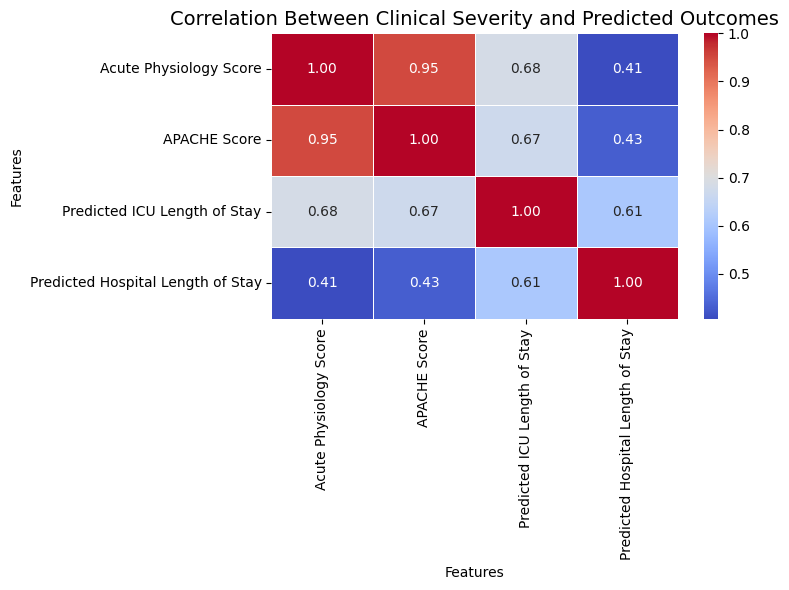

In [119]:
rename_cols = {
    "acutephysiologyscore": "Acute Physiology Score",
    "apachescore": "APACHE Score",
    "predictediculos": "Predicted ICU Length of Stay",
    "predictedhospitallos": "Predicted Hospital Length of Stay"
}

corr_cols = list(rename_cols.keys())

available_corr_cols = [col for col in corr_cols if col in apache_patient_result.columns]

#compute correlation
corr_matrix = apache_patient_result[available_corr_cols].corr()

#rename for display
corr_matrix.rename(index=rename_cols, columns=rename_cols, inplace=True)

#plot
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Between Clinical Severity and Predicted Outcomes", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

**Correlation Analysis Summary**

The correlation heatmap shows strong relationships between some clinical features. In particular, the acute physiology score and APACHE score are highly correlated, suggesting they capture similar information about patient severity.

Other variables, such as predicted ICU and hospital length of stay, show moderate correlations. These relationships help identify potential redundancy and guide feature selection in later stages.

**EDA Summary**

The exploratory data analysis revealed several key insights:

- The dataset contains a class imbalance, with more surviving patients than deceased patients.

- Several APACHE-related variables have high missingness and required cleaning.

- Numerical features such as APACHE scores show skewed distributions and contain outliers.

- Some features are strongly correlated, indicating potential redundancy.

These findings guided the data cleaning and preprocessing steps.

### 3.2 Data Integration

In this step, multiple datasets were combined to create a unified dataset for analysis. The patient dataset was used as the base table, and additional clinical information from APACHE-related tables was integrated.

Since the APACHE tables contain multiple records per patient due to repeated measurements, the data was first aggregated using patientunitstayid to ensure that each patient is represented by a single row. For numerical variables, the mean value was used to summarize patient information, while for categorical or outcome-related tables, the first available record was retained.

After aggregation, the datasets were merged using patientunitstayid as the key. A left join strategy was applied to preserve all patient records while incorporating relevant clinical features.

Following the merge, duplicate columns created during the process were identified and removed to maintain a clean and consistent dataset structure. A final validation step confirmed that there were no duplicate patient IDs, ensuring a correct one-row-per-patient format.

This integration step ensures that all relevant patient, clinical, and severity-related information is combined into a single dataset, enabling effective preprocessing and model development.


#### 3.2.1 Aggregate APACHE Tables

In [120]:
#aggregate only numeric columns for APACHE numeric tables

apache_pred_var_agg = (
    apache_pred_var
    .groupby("patientunitstayid")
    .mean(numeric_only=True)
    .reset_index()
)

apache_aps_var_agg = (
    apache_aps_var
    .groupby("patientunitstayid")
    .mean(numeric_only=True)
    .reset_index()
)

#keep one row per patient for apache_patient_result

apache_patient_result_agg = (
    apache_patient_result
    .groupby("patientunitstayid")
    .first()
    .reset_index()
)

#### 3.2.2 Merge Datasets

The APACHE tables contain multiple rows per patient due to repeated measurements over time. To ensure that each patient is represented by a single row, the data was aggregated using `patientunitstayid`.

The mean was used to summarize numeric variables, as it provides a simple representation of overall patient condition across multiple measurements. This allows consistent merging with the main patient dataset.

**Note:** An initial merge was attempted using the original tables, but it resulted in duplicate patient records. This was corrected by aggregating the data before merging.


In [121]:
#merging Datasets using aggregated tables

merged_df = patient.merge(
    apache_patient_result_agg,
    on="patientunitstayid",
    how="left"
)

merged_df = merged_df.merge(
    apache_pred_var_agg,
    on="patientunitstayid",
    how="left"
)

merged_df = merged_df.merge(
    apache_aps_var_agg,
    on="patientunitstayid",
    how="left"
)

print("Merged shape:", merged_df.shape)
display(merged_df.head())

Merged shape: (2520, 126)


,patientunitstayid,patienthealthsystemstayid,gender_x,age_x,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,ph,hematocrit,creatinine_y,albumin,pao2_y,pco2,bun,glucose,bilirubin,fio2_y
0,141764,129391,Female,87,Caucasian,59,91,NaN,157.5,23:36:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,141765,129391,Female,87,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",157.5,23:36:00,...,-1.0,37.8,1.04,-1.0,-1.0,-1.0,28.0,61.0,-1.0,-1.0
2,143870,131022,Male,76,Caucasian,68,103,"Endarterectomy, carotid",167.0,20:46:00,...,-1.0,34.1,1.14,-1.0,-1.0,-1.0,14.0,140.0,-1.0,-1.0
3,144815,131736,Female,34,Caucasian,56,82,"Overdose, other toxin, poison or drug",172.7,01:44:00,...,-1.0,36.6,0.63,3.6,-1.0,-1.0,6.0,82.0,0.5,-1.0
4,145427,132209,Male,61,Caucasian,68,103,"GI perforation/rupture, surgery for",177.8,23:48:00,...,-1.0,40.4,1.05,-1.0,-1.0,-1.0,14.0,118.0,-1.0,-1.0


#### 3.2.3 Handle Duplicate Columns

After merging, duplicate columns with suffixes '_x' and '_y' were created. These columns represent the same variables from different tables.

After verifying that they contain redundant information, the '_y' columns were removed to avoid duplication and keep the dataset clean.

In [122]:
cols_to_drop = [col for col in merged_df.columns if col.endswith("_y")]
merged_df = merged_df.drop(columns=cols_to_drop)

merged_df.columns = [col.replace("_x", "") for col in merged_df.columns]

print("Shape after fixing duplicate columns:", merged_df.shape)

Shape after fixing duplicate columns: (2520, 117)


#### 3.2.4 Validate Merge

In [123]:
#check duplicate patient IDs after merging

duplicate_ids = merged_df["patientunitstayid"].duplicated().sum()
print("Number of duplicated patientunitstayid values:", duplicate_ids)

Number of duplicated patientunitstayid values: 0


**Merge Summary**

The initial merge produced duplicate patient records because some APACHE tables contained multiple rows for the same `patientunitstayid`. To fix this, aggregated versions of the APACHE tables were created before merging so that each patient was represented by only one row.

For the numerical APACHE tables, values were aggregated by taking the mean for each patient. For `apache_patient_result`, the first available row for each patient was kept. After applying this correction, the merged dataset contained 2520 rows with no duplicated patient IDs, creating a valid one-patient-per-row structure for machine learning.

### 3.3 Data Cleaning

In this step, the merged dataset is cleaned to prepare it for downstream machine learning tasks. This includes identifying missing values, removing columns with excessive missing data, removing leakage columns, and inspecting the remaining missing values before later preprocessing.

#### 3.3.1 Missing Values Assessment

In this step, missing values in the merged dataset are analyzed to understand the extent of incomplete data across features. Both the count and percentage of missing values are calculated for each column.

This helps identify which variables contain excessive missing data and guides decisions on whether to remove or retain specific features before further preprocessing.

In [124]:
#check missing values

missing_counts = merged_df.isnull().sum()
missing_percent = (merged_df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing %": missing_percent
})

missing_summary = missing_summary[missing_summary["Missing Count"] > 0]
missing_summary = missing_summary.sort_values(by="Missing %", ascending=False)

display(missing_summary.head(20))

,Missing Count,Missing %
electivesurgery,2178,86.43
predventdays,2018,80.08
unabridgedactualventdays,1999,79.33
actualventdays,1999,79.33
dischargeweight,1284,50.95
preopmi,682,27.06
predictedhospitallos,682,27.06
actualhospitallos,682,27.06
acutephysiologyscore,682,27.06
predictedicumortality,682,27.06


#### 3.3.2 Drop High-Missing Columns

Columns with more than 70% missing values are removed from the dataset, as they provide limited useful information and may negatively affect model performance.

A relatively high threshold (70%) was used to retain important clinical features, since moderate levels of missing data are common in healthcare datasets. This ensures that valuable information is not lost unnecessarily.

In [125]:
#drop columns with >70% missing values

cols_to_drop = missing_summary[missing_summary["Missing %"] > 70].index

clean_df = merged_df.drop(columns=cols_to_drop)

print("Dropped columns:", list(cols_to_drop))
print("New shape:", clean_df.shape)

Dropped columns: ['electivesurgery', 'predventdays', 'unabridgedactualventdays', 'actualventdays']
New shape: (2520, 113)


In [126]:
remove_keywords = ["discharge", "mortality", "los", "expired", "died"]

cols_to_remove = [
    col for col in clean_df.columns
    if any(word in col.lower() for word in remove_keywords)
    and col != "target_mortality"
]

print(cols_to_remove)

['hospitaldischargeyear', 'hospitaldischargetime24', 'hospitaldischargeoffset', 'hospitaldischargelocation', 'hospitaldischargestatus', 'dischargeweight', 'unitdischargetime24', 'unitdischargeoffset', 'unitdischargelocation', 'unitdischargestatus', 'predictedicumortality', 'actualicumortality', 'predictediculos', 'actualiculos', 'predictedhospitalmortality', 'actualhospitalmortality', 'predictedhospitallos', 'actualhospitallos', 'unabridgedunitlos', 'unabridgedhosplos', 'diedinhospital', 'var03hspxlos', 'dischargelocation']


#### 3.3.3 Remove Leakage Features

Data leakage occurs when the model has access to information that would not be available at the time of prediction. This can result in unrealistically high performance, as the model is indirectly using the outcome it is supposed to predict.

In this dataset, columns related to predicted or actual mortality are considered leakage because they already contain outcome information. These features are removed to ensure that the model learns from valid input variables rather than relying on precomputed results.

Multiple sequential checks were used in this section to remove direct leakage, post-outcome variables, suspicious renamed columns, and invalid infinite values before feature engineering and model training.

In [127]:
# removing leakage and post-outcome columns

leakage_cols = [
    # direct target leakage
    "hospitaldischargestatus",
    "actualhospitalmortality",
    "actualicumortality",
    "predictedhospitalmortality",
    "predictedicumortality",
    "diedinhospital",

    # discharge / post-outcome information
    "hospitaldischargelocation",
    "unitdischargestatus",
    "unitdischargelocation",
    "dischargelocation",
    "hospitaldischargeoffset",
    "hospitaldischargetime24",
    "unitdischargeoffset",
    "unitdischargetime24",

    # actual outcomes that happen after admission
    "actualiculos",
    "actualhospitallos",
    "unabridgedunitlos",
    "unabridgedhosplos",
    "actualventdays",
    "unabridgedactualventdays",

    # optional: remove model-generated predicted outcome summaries too
    "predictediculos",
    "predictedhospitallos",
    "predventdays"
]

clean_df = clean_df.drop(columns=[col for col in leakage_cols if col in clean_df.columns])

print("Removed leakage/post-outcome columns:")
print([col for col in leakage_cols if col in merged_df.columns or col in clean_df.columns])

print("Shape after removing leakage columns:", clean_df.shape)

Removed leakage/post-outcome columns:
['hospitaldischargestatus', 'actualhospitalmortality', 'actualicumortality', 'predictedhospitalmortality', 'predictedicumortality', 'diedinhospital', 'hospitaldischargelocation', 'unitdischargestatus', 'unitdischargelocation', 'dischargelocation', 'hospitaldischargeoffset', 'hospitaldischargetime24', 'unitdischargeoffset', 'unitdischargetime24', 'actualiculos', 'actualhospitallos', 'unabridgedunitlos', 'unabridgedhosplos', 'actualventdays', 'unabridgedactualventdays', 'predictediculos', 'predictedhospitallos', 'predventdays']
Shape after removing leakage columns: (2520, 93)


In [128]:
print("Remaining possible suspicious columns:")
suspicious_cols = [col for col in clean_df.columns if any(word in col.lower() for word in [
    "death", "mortality", "discharge", "expired", "los", "ventdays"
])]
print(suspicious_cols)

Remaining possible suspicious columns:
['hospitaldischargeyear', 'dischargeweight', 'target_mortality', 'var03hspxlos']


In [129]:
import numpy as np

# Replace inf / -inf with NaN
clean_df = clean_df.replace([np.inf, -np.inf], np.nan)

print("Infinity values replaced with NaN.")

Infinity values replaced with NaN.


In [130]:
remove_keywords = ["discharge", "mortality", "expired", "died"]

cols_to_remove = [
    col for col in clean_df.columns
    if any(word in col.lower() for word in remove_keywords)
]

# keep target only
cols_to_remove = [c for c in cols_to_remove if c != "target_mortality"]

clean_df = clean_df.drop(columns=cols_to_remove)

print("Removed:", cols_to_remove)

Removed: ['hospitaldischargeyear', 'dischargeweight']


In [131]:
extra = ["var03hspxlos"]
clean_df = clean_df.drop(columns=[c for c in extra if c in clean_df.columns])

In [132]:
print([col for col in clean_df.columns if "discharge" in col.lower() or "los" in col.lower() or "mortality" in col.lower()])

['target_mortality']


In [133]:
cols_to_remove = [
    "hospitaldischargeyear",
    "hospitaldischargeoffset",
    "hospitaldischargelocation",
    "hospitaldischargestatus",
    "unitdischargetime24",
    "unitdischargelocation",
    "unitdischargestatus",
    "unitdischargeoffset",
    "dischargeweight",
    "var03hspxlos"
]

clean_df = clean_df.drop(columns=[col for col in cols_to_remove if col in clean_df.columns])

In [134]:
keywords = ["los", "death", "expire", "mort", "status", "year"]
sus = [col for col in clean_df.columns if any(k in col.lower() for k in keywords)]
print(sus)

['target_mortality']


In [135]:
print(clean_df.shape)

(2520, 90)


#### 3.3.4 Inspect Remaining Missing Values

After removing columns with excessive missing data, the remaining missing values were inspected but not imputed at this stage.

Final imputation will be performed later after splitting the data into training and testing sets. This helps prevent data leakage and ensures that imputation statistics are learned only from the training data.

In [136]:
remaining_missing = clean_df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

print("Remaining missing values after structural cleaning:")
display(remaining_missing.head(20))

print("Total remaining missing values:", clean_df.isnull().sum().sum())
print("Current shape:", clean_df.shape)

Remaining missing values after structural cleaning:


,0
apacheversion,682
apachescore,682
physicianinterventioncategory,682
acutephysiologyscore,682
apachepatientresultsid,682
physicianspeciality,682
preopcardiaccath,682
ptcawithin24h,682
preopmi,682
hospitaladmitsource,594


Total remaining missing values: 26582
Current shape: (2520, 90)


#### 3.3.5 Final Dataset Overview

In [137]:
print("Final dataset shape before train-test split:", clean_df.shape)

print("\nColumn data types:")
display(clean_df.dtypes)

print("\nTotal remaining missing values:")
print(clean_df.isnull().sum().sum())

print("\nPreview of cleaned dataset:")
display(clean_df.head())

Final dataset shape before train-test split: (2520, 90)

Column data types:


,0
patientunitstayid,int64
patienthealthsystemstayid,int64
gender,object
age,object
ethnicity,object
...,...
albumin,float64
pco2,float64
bun,float64
glucose,float64



Total remaining missing values:
26582

Preview of cleaned dataset:


,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,sodium,heartrate,meanbp,ph,hematocrit,albumin,pco2,bun,glucose,bilirubin
0,141764,129391,Female,87,Caucasian,59,91,NaN,157.5,23:36:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,141765,129391,Female,87,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",157.5,23:36:00,...,139.0,88.0,108.0,-1.0,37.8,-1.0,-1.0,28.0,61.0,-1.0
2,143870,131022,Male,76,Caucasian,68,103,"Endarterectomy, carotid",167.0,20:46:00,...,133.0,40.0,47.0,-1.0,34.1,-1.0,-1.0,14.0,140.0,-1.0
3,144815,131736,Female,34,Caucasian,56,82,"Overdose, other toxin, poison or drug",172.7,01:44:00,...,141.0,131.0,61.0,-1.0,36.6,3.6,-1.0,6.0,82.0,0.5
4,145427,132209,Male,61,Caucasian,68,103,"GI perforation/rupture, surgery for",177.8,23:48:00,...,141.0,49.0,72.0,-1.0,40.4,-1.0,-1.0,14.0,118.0,-1.0


**Cleaning Summary**

Missing values were handled using the following approach:

- Columns with more than 70% missing values were removed, as they contain insufficient information for reliable analysis.

- Remaining missing values were preserved at this stage and will be imputed later during preprocessing after the train-test split.

This approach ensures that missing data is handled in a way that avoids data leakage while preserving the structure of the dataset.

The 70% threshold was chosen to balance data retention and quality, as columns with excessive missingness can introduce noise and reduce model reliability.


### 3.4 Data Transformation

In this step, data transformation techniques such as handling missing values, scaling numerical features, and encoding categorical variables are defined. To avoid data leakage, these transformations are implemented using a preprocessing pipeline and applied later during model training after splitting the data.

In [138]:
# Separate features and target
X = clean_df.drop(columns=["target_mortality"])
y = clean_df["target_mortality"]

# Identify column types
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

# Create pipelines
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine into full preprocessor
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully.")
print("Numeric features:", list(numeric_features))
print("Categorical features:", list(categorical_features))

Preprocessing pipeline created successfully.
Numeric features: ['patientunitstayid', 'patienthealthsystemstayid', 'hospitalid', 'wardid', 'admissionheight', 'hospitaladmitoffset', 'unitvisitnumber', 'admissionweight', 'apachepatientresultsid', 'acutephysiologyscore', 'apachescore', 'preopmi', 'preopcardiaccath', 'ptcawithin24h', 'apachepredvarid', 'sicuday', 'saps3day1', 'saps3today', 'saps3yesterday', 'teachtype', 'region', 'bedcount', 'admitsource', 'graftcount', 'meds', 'verbal', 'motor', 'eyes', 'thrombolytics', 'aids', 'hepaticfailure', 'lymphoma', 'metastaticcancer', 'leukemia', 'immunosuppression', 'cirrhosis', 'activetx', 'readmit', 'ima', 'midur', 'ventday1', 'oobventday1', 'oobintubday1', 'diabetes', 'managementsystem', 'pao2', 'fio2', 'ejectfx', 'creatinine', 'visitnumber', 'amilocation', 'day1meds', 'day1verbal', 'day1motor', 'day1eyes', 'day1pao2', 'day1fio2', 'apacheapsvarid', 'intubated', 'vent', 'dialysis', 'urine', 'wbc', 'temperature', 'respiratoryrate', 'sodium', 'he

In [139]:
print("Any inf in X:", np.isinf(X.select_dtypes(include=np.number)).sum().sum())

print("Any NaN in X:", X.isna().sum().sum())

print("Columns with inf values:")
num_cols = X.select_dtypes(include=np.number).columns

inf_cols = [col for col in num_cols if np.isinf(X[col]).any()]
print(inf_cols)

Any inf in X: 0
Any NaN in X: 26582
Columns with inf values:
[]


In [140]:
num_cols = X.select_dtypes(include=np.number).columns

for col in num_cols:
    X[col] = pd.to_numeric(X[col], errors="coerce")
    X[col] = X[col].replace([np.inf, -np.inf], np.nan)

In [141]:
print("X contains target column:", "target_mortality" in X.columns)

X contains target column: False


**Transformation Summary**

The preprocessing pipeline was successfully defined to prepare the dataset for model training.

The transformations will be applied during model training to prevent data leakage.

Numerical features will be imputed using the median and scaled using `StandardScaler`, while categorical features will be imputed using the most frequent value and encoded using `OneHotEncoder`.

This ensures that all features are in a suitable format for machine learning models and improves performance and consistency.

---

## Stage 4: Feature Engineering

In this stage, relevant features are selected and refined to improve model performance. This includes identifying the most informative variables and removing unnecessary or redundant features.

The goal is to create a meaningful set of features that accurately represent the underlying patterns in the data and enhance the model’s ability to make predictions.



### 4.1 Feature Creation

In this stage, new features were created from clinically meaningful existing variables to improve representation of patient risk.

Two engineered features were added:

- **`is_senior`**: a binary feature indicating whether the patient is 65 years or older.
- **`bun_log`**: a log-transformed version of blood urea nitrogen (BUN), created to reduce skewness in this laboratory variable.

These features were added before rebuilding the final modeling dataset so they could be included in training and evaluation.

In [142]:
# create a binary age group feature

# convert age to numeric
clean_df["age"] = pd.to_numeric(clean_df["age"], errors="coerce")

clean_df["is_senior"] = (clean_df["age"] >= 65).astype(int)

print("New feature created: is_senior")
display(clean_df[["age", "is_senior"]].head())

New feature created: is_senior


,age,is_senior
0,87.0,1
1,87.0,1
2,76.0,1
3,34.0,0
4,61.0,0


**Feature Creation Summary**

In this step, a new feature (`is_senior`) was created based on patient age to capture whether a patient is considered elderly (age ≥ 65). This transformation helps simplify age-related patterns and may improve model performance by highlighting a clinically meaningful threshold.

The original `age` variable was first converted to a numeric format to ensure correct comparisons. No additional features were created, as the existing variables already provide sufficient information for the prediction task.

### 4.2 Feature Transformation

Feature transformation was applied to improve data quality and model readiness.

In this project:

- **Age** was converted to numeric format before creating the `is_senior` feature.
- **BUN** was converted to numeric format and transformed using **`log1p`** after handling invalid values.
- After feature engineering, any remaining infinite values were replaced with missing values (`NaN`) to avoid downstream model errors.

Additional transformations such as scaling numerical variables and encoding categorical variables were handled later through the preprocessing pipeline during model training.

In [143]:
#log transform a numeric column (if exists)
if "bun" in clean_df.columns:
    clean_df["bun"] = pd.to_numeric(clean_df["bun"], errors="coerce")

    # replace invalid values BEFORE log
    clean_df["bun"] = clean_df["bun"].replace([0, np.inf, -np.inf], np.nan)

    clean_df["bun_log"] = np.log1p(clean_df["bun"].clip(lower=0))
    print("bun_log created safely.")

    print("Applied log transformation to 'bun'")
    display(clean_df[["bun", "bun_log"]].head())

bun_log created safely.
Applied log transformation to 'bun'


,bun,bun_log
0,NaN,NaN
1,28.0,3.367296
2,14.0,2.708050
3,6.0,1.945910
4,14.0,2.708050


In [144]:
clean_df = clean_df.replace([np.inf, -np.inf], np.nan)
print("Post-feature-engineering inf values replaced with NaN.")

Post-feature-engineering inf values replaced with NaN.


**Feature Transformation Summary**

In this step, a log transformation was applied to the `bun` variable using `log1p` to reduce skewness while safely handling zero values. Age was also converted into a binary risk-related feature through `is_senior`.

After feature engineering, infinite values were replaced with missing values (`NaN`) to avoid numerical issues in later model training. Final scaling and encoding were not performed here directly, since they were handled later through the preprocessing pipeline.

In [145]:
# Rebuild X and y after feature engineering
X = clean_df.drop(columns=["target_mortality"])
y = clean_df["target_mortality"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Updated X, y, and preprocessor after feature engineering.")
print("X shape:", X.shape)

Updated X, y, and preprocessor after feature engineering.
X shape: (2520, 91)


### 4.3 Initial Feature Filtering & Domain Selection

At this stage, an initial subset of clinically relevant variables was reviewed based on domain knowledge. This included demographic features, hospital-related context, admission characteristics, and selected laboratory information such as `bun_log`.

This step was used to demonstrate domain-based feature review and filtering logic. However, the final machine learning models were trained using the broader cleaned dataset (`clean_df`) after leakage removal and feature engineering, rather than only this smaller manually selected subset.

Outcome-related and post-discharge variables had already been removed earlier to prevent data leakage.

In [146]:
#select relevant features from the cleaned dataset

patient_selected = clean_df[[
    "patientunitstayid",
    "age",
    "is_senior",
    "gender",
    "ethnicity",
    "hospitalid",
    "unittype",
    "unitadmitsource",
    "unitstaytype",
    "bun_log",
    "target_mortality"
]].copy()

print("Shape:", patient_selected.shape)
display(patient_selected.head())

Shape: (2520, 11)


,patientunitstayid,age,is_senior,gender,ethnicity,hospitalid,unittype,unitadmitsource,unitstaytype,bun_log,target_mortality
0,141764,87.0,1,Female,Caucasian,59,Med-Surg ICU,ICU to SDU,stepdown/other,NaN,0
1,141765,87.0,1,Female,Caucasian,59,Med-Surg ICU,Emergency Department,admit,3.367296,0
2,143870,76.0,1,Male,Caucasian,68,SICU,Operating Room,admit,2.708050,0
3,144815,34.0,0,Female,Caucasian,56,Med-Surg ICU,Emergency Department,admit,1.945910,0
4,145427,61.0,0,Male,Caucasian,68,SICU,Operating Room,admit,2.708050,0


**Feature Selection Summary**

This step presents an initial domain-based review of clinically meaningful variables, including demographic information, hospital context, admission characteristics, and engineered features such as `is_senior` and `bun_log`.

This smaller subset was used to demonstrate manual feature filtering based on clinical relevance. However, the final machine learning models were trained using the broader cleaned dataset after leakage removal and feature engineering, rather than only this manually selected subset.



### 4.4 Dimensionality Reduction

Principal Component Analysis (PCA) was applied to the numeric portion of the cleaned dataset as an exploratory dimensionality reduction step. The goal was to inspect how much variance could be summarized in a smaller number of components.

PCA was used only for analysis and dimensionality inspection. It was **not** used in the final training pipeline, since the final models were trained on the original cleaned feature space after preprocessing.

In [147]:
from sklearn.decomposition import PCA

#select numeric columns only
numeric_df = clean_df.select_dtypes(include=["number"]).drop(columns=["target_mortality"], errors="ignore")

#replace inf values with NaN
numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan)

#fill missing values after replacing inf
numeric_df = numeric_df.fillna(0)

#apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(numeric_df)

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.61507738 0.21558637]


**Dimensionality Reduction Summary**

In this step, PCA was applied as an exploratory dimensionality reduction technique to inspect how much variance could be captured in fewer components. This provided insight into the structure of the numeric feature space and the degree of redundancy among variables.

Although PCA was useful for analysis, it was not included in the final modeling pipeline. The final models were trained on the cleaned and preprocessed original feature space instead.

---

## Stage 5: Model Training

In this stage, multiple machine learning models are trained to predict patient mortality. Different classification algorithms are applied to the prepared dataset to establish baseline performance.

The goal is to evaluate how well each model learns from the data and to identify the most effective models for further improvement and tuning.

#### 5.1 Select Appropriate Algorithms

In this step, multiple classification algorithms are selected to predict patient mortality. These models provide baseline performance and allow comparison of different learning approaches.

The selected algorithms include Logistic Regression, Decision Tree, Random Forest, Support Vector Machine, K-Nearest Neighbors,  Naive Bayes, Gradient Boosting, and XGBoost

In [148]:
models = {
    "Logistic Regression": LogisticRegression(
    C=1,
    solver="liblinear",
    class_weight="balanced",
    max_iter=3000,
    random_state=42
),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    "SVM": SVC(
    probability=True,
    class_weight="balanced",
    C=1,
    kernel="rbf",
    random_state=42
),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=(y==0).sum()/(y==1).sum(),
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05
)
}

#### 5.2 Split Data (Train/Validation/Test)

In this stage, the dataset is divided into separate subsets to support model training and evaluation. The data is first split into training and test sets, ensuring that model performance is evaluated on unseen data.

The training data is then further split into a training set and a validation set. The validation set is used to compare models and tune hyperparameters, while the test set remains untouched until the final evaluation.

This approach helps ensure fair performance assessment and reduces the risk of overfitting.

##### 5.2.1 First Split (Train/Test)

In this step, the dataset is divided into training and test sets. The training set is used to train the models, while the test set is reserved for final evaluation.

Stratified sampling is applied to preserve the original class distribution in both sets, ensuring a balanced and reliable split.

In [149]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train set:", X_train.shape)
print("Test set :", X_test.shape)
print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))

Train set: (2016, 91)
Test set : (504, 91)

Train class distribution:
target_mortality
0    0.915675
1    0.084325
Name: proportion, dtype: float64


**First Split Summary**

The dataset was successfully split into training and test sets, with 80% of the data used for training and 20% reserved for testing.

Stratification ensured that the class distribution remained consistent across both sets, supporting fair model evaluation.

##### 5.2.2 Second Split (Train → Train + Validation)

In this step, the training data is further divided into a final training set and a validation set. The validation set is used to evaluate model performance during training and support hyperparameter tuning.

Stratification is applied to maintain consistent class distribution across both subsets.

In [150]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Train final:", X_train_final.shape)
print("Validation :", X_val.shape)
print("Test       :", X_test.shape)

print("\nClass distribution:")
print(y_train_final.value_counts(normalize=True))

Train final: (1612, 91)
Validation : (404, 91)
Test       : (504, 91)

Class distribution:
target_mortality
0    0.915633
1    0.084367
Name: proportion, dtype: float64


**Second Split Summary**

The training data was further split into a final training set and a validation set.

The final training set is used for model learning, while the validation set is used for performance comparison and tuning.

This ensures a reliable and structured evaluation process before testing on unseen data.

##### 5.2.3 Adversarial Condition Injection

To simulate real-world challenges, adversarial conditions are introduced into the training data. In this project, label noise is introduced by randomly flipping 10% of the training labels.

This approach helps evaluate how robust the models are when dealing with imperfect or noisy data, which is common in real-world scenarios.

Other adversarial techniques such as SMOTE, class weighting, or feature distribution shifts (concept drift) were considered. However, label noise injection was selected because it directly simulates real-world mislabeling and provides a clear evaluation of model robustness.

In [151]:
np.random.seed(42)

y_train_final_noisy = y_train_final.copy()

noise_ratio = 0.10
n_noisy = int(noise_ratio * len(y_train_final_noisy))

noise_idx = np.random.choice(y_train_final_noisy.index, size=n_noisy, replace=False)
y_train_final_noisy.loc[noise_idx] = 1 - y_train_final_noisy.loc[noise_idx]

print(f"Injected label noise into {n_noisy} samples ({noise_ratio*100:.0f}%).")

Injected label noise into 161 samples (10%).


**Adversarial Summary**

Adversarial conditions were introduced by injecting 10% label noise into the final training set.

A total of **161 training samples** had their labels flipped, simulating real-world data imperfections such as mislabeling. This setup was used later to compare clean baseline performance against robustness under noisy labels.

#### 5.3 Train Baseline Models

In this stage, multiple machine learning models are trained using the final training set and evaluated on the validation set. These models provide a baseline for performance comparison before applying hyperparameter tuning.

Each model is trained using the same preprocessing pipeline to ensure consistency and fairness in evaluation. The models are then assessed using key performance metrics including **accuracy**, **precision**, **recall**, **F1-score**, and **AUC-ROC**.

The goal is to identify the most promising models based on their performance and prepare them for further optimization. Because mortality is the minority class, model comparison focused primarily on **F1-score, recall, and AUC-ROC**, rather than accuracy alone.

In [152]:
def get_scores(model_pipeline, X_data):
    """
    Return probability scores if available, else decision function scores,
    else predicted labels as fallback.
    """
    if hasattr(model_pipeline, "predict_proba"):
        return model_pipeline.predict_proba(X_data)[:, 1]
    elif hasattr(model_pipeline, "decision_function"):
        return model_pipeline.decision_function(X_data)
    else:
        return model_pipeline.predict(X_data)


def evaluate_model(model_pipeline, X_true, y_true, model_name="Model"):
    thresholds = {
        "Logistic Regression": 0.30,
        "XGBoost": 0.40,
        "Random Forest": 0.35,
        "Gradient Boosting": 0.35
    }

    threshold = 0.50
    for key, value in thresholds.items():
        if key in model_name:
            threshold = value
            break

    y_score = get_scores(model_pipeline, X_true)

    if hasattr(model_pipeline, "predict_proba"):
        y_pred = (y_score >= threshold).astype(int)
    else:
        y_pred = model_pipeline.predict(X_true)

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "AUC-ROC": roc_auc_score(y_true, y_score)
    }
    return results

def plot_confusion_matrices(trained_models, X_data, y_true, title_prefix="Validation"):
    thresholds = {
        "Logistic Regression": 0.30,
        "XGBoost": 0.40,
        "Random Forest": 0.35,
        "Gradient Boosting": 0.35
    }

    n_models = len(trained_models)
    rows = int(np.ceil(n_models / 3))
    cols = 3

    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for i, (name, pipeline) in enumerate(trained_models.items()):
        y_score = get_scores(pipeline, X_data)

        threshold = 0.50
        for key, value in thresholds.items():
            if key in name:
                threshold = value
                break

        if hasattr(pipeline, "predict_proba"):
            y_pred = (y_score >= threshold).astype(int)
        else:
            y_pred = pipeline.predict(X_data)

        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(ax=axes[i], colorbar=False)
        axes[i].set_title(f"{title_prefix} - {name}")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


def plot_roc_curves(trained_models, X_data, y_true, title="ROC Curves"):
    plt.figure(figsize=(10, 7))

    for name, pipeline in trained_models.items():
        y_score = get_scores(pipeline, X_data)
        fpr, tpr, _ = roc_curve(y_true, y_score)
        auc = roc_auc_score(y_true, y_score)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()

##### 5.3.1 Model Training

In this step, multiple baseline machine learning models are trained using the final training set. Each model is combined with the preprocessing pipeline to ensure consistent data handling and fair comparison. The goal is to build initial models that can later be evaluated and improved.

In [153]:
print("Any inf in X:", np.isinf(X.select_dtypes(include=np.number)).sum().sum())

num_cols = X.select_dtypes(include=np.number).columns
inf_cols = [col for col in num_cols if np.isinf(X[col]).any()]
print("Columns with inf:", inf_cols)

Any inf in X: 0
Columns with inf: []


In [154]:
baseline_results = []
trained_models = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train_final, y_train_final)   # CLEAN baseline

    result = evaluate_model(
        pipeline,
        X_val,
        y_val,
        model_name=name
    )

    baseline_results.append(result)
    trained_models[name] = pipeline

    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
SVM trained successfully.
KNN trained successfully.
Naive Bayes trained successfully.
Gradient Boosting trained successfully.
XGBoost trained successfully.


**Training Summary**

All baseline models were successfully trained using the final training set and evaluated on the validation set.

The baseline stage provided an initial comparison across multiple classifiers, including linear, tree-based, probabilistic, distance-based, and boosting methods. This established the reference performance needed for later adversarial testing, hyperparameter tuning, feature selection, and ensemble comparison.

##### 5.3.2 Model Evaluation

Each baseline model was evaluated on the validation set using **accuracy, precision, recall, F1-score, and AUC-ROC**.

Because the dataset is imbalanced and mortality cases are relatively rare, **F1-score, recall, and AUC-ROC were emphasized more than accuracy** when comparing models. In addition, model-specific decision thresholds were used for selected classifiers to improve minority-class detection.

In [155]:
baseline_results_df = pd.DataFrame(baseline_results).sort_values(
    by=["F1-score", "AUC-ROC"], ascending=False
)

baseline_results_df

,Model,Accuracy,Precision,Recall,F1-score,AUC-ROC
7,XGBoost,0.792079,0.202381,0.500000,0.288136,0.789666
0,Logistic Regression,0.814356,0.194030,0.382353,0.257426,0.756200
1,Decision Tree,0.849010,0.200000,0.264706,0.227848,0.583704
6,Gradient Boosting,0.923267,0.800000,0.117647,0.205128,0.774205
5,Naive Bayes,0.821782,0.148148,0.235294,0.181818,0.555485
2,Random Forest,0.915842,0.500000,0.088235,0.150000,0.772576
3,SVM,0.913366,0.333333,0.029412,0.054054,0.746184
4,KNN,0.905941,0.166667,0.029412,0.050000,0.674126


**Evaluation Summary**

The baseline results showed that **XGBoost** achieved the strongest overall validation performance, with the highest F1-score (**0.288**) and the highest AUC-ROC (**0.790**). **Logistic Regression** provided the next strongest baseline and remained useful as an interpretable comparison model.

Other models such as Decision Tree, Naive Bayes, Random Forest, SVM, and KNN showed weaker minority-class performance, especially in recall or F1-score. Based on these results, stronger candidate models were selected for further improvement through hyperparameter tuning.

##### 5.3.3 Confusion Matrices

In this step, confusion matrices are used to evaluate the classification performance of each model. They provide a detailed breakdown of correct and incorrect predictions for each class, helping identify model strengths and weaknesses.

In [183]:
def plot_confusion_matrices(trained_models, X_data, y_true, title_prefix="Validation"):
    thresholds = {
        "Logistic Regression": 0.30,
        "XGBoost": 0.40,
        "Random Forest": 0.35,
        "Gradient Boosting": 0.35
    }

    n_models = len(trained_models)
    rows = int(np.ceil(n_models / 3))
    cols = 3

    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for i, (name, pipeline) in enumerate(trained_models.items()):
        y_score = get_scores(pipeline, X_data)

        threshold = 0.50
        for key, value in thresholds.items():
            if key in name:
                threshold = value
                break

        if hasattr(pipeline, "predict_proba"):
            y_pred = (y_score >= threshold).astype(int)
        else:
            y_pred = pipeline.predict(X_data)

        cm = confusion_matrix(y_true, y_pred)

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=True,
            cbar_kws={"label": "Count"},
            ax=axes[i]
        )

        axes[i].set_title(f"{title_prefix} - {name}")
        axes[i].set_xlabel("Predicted Label")
        axes[i].set_ylabel("True Label")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

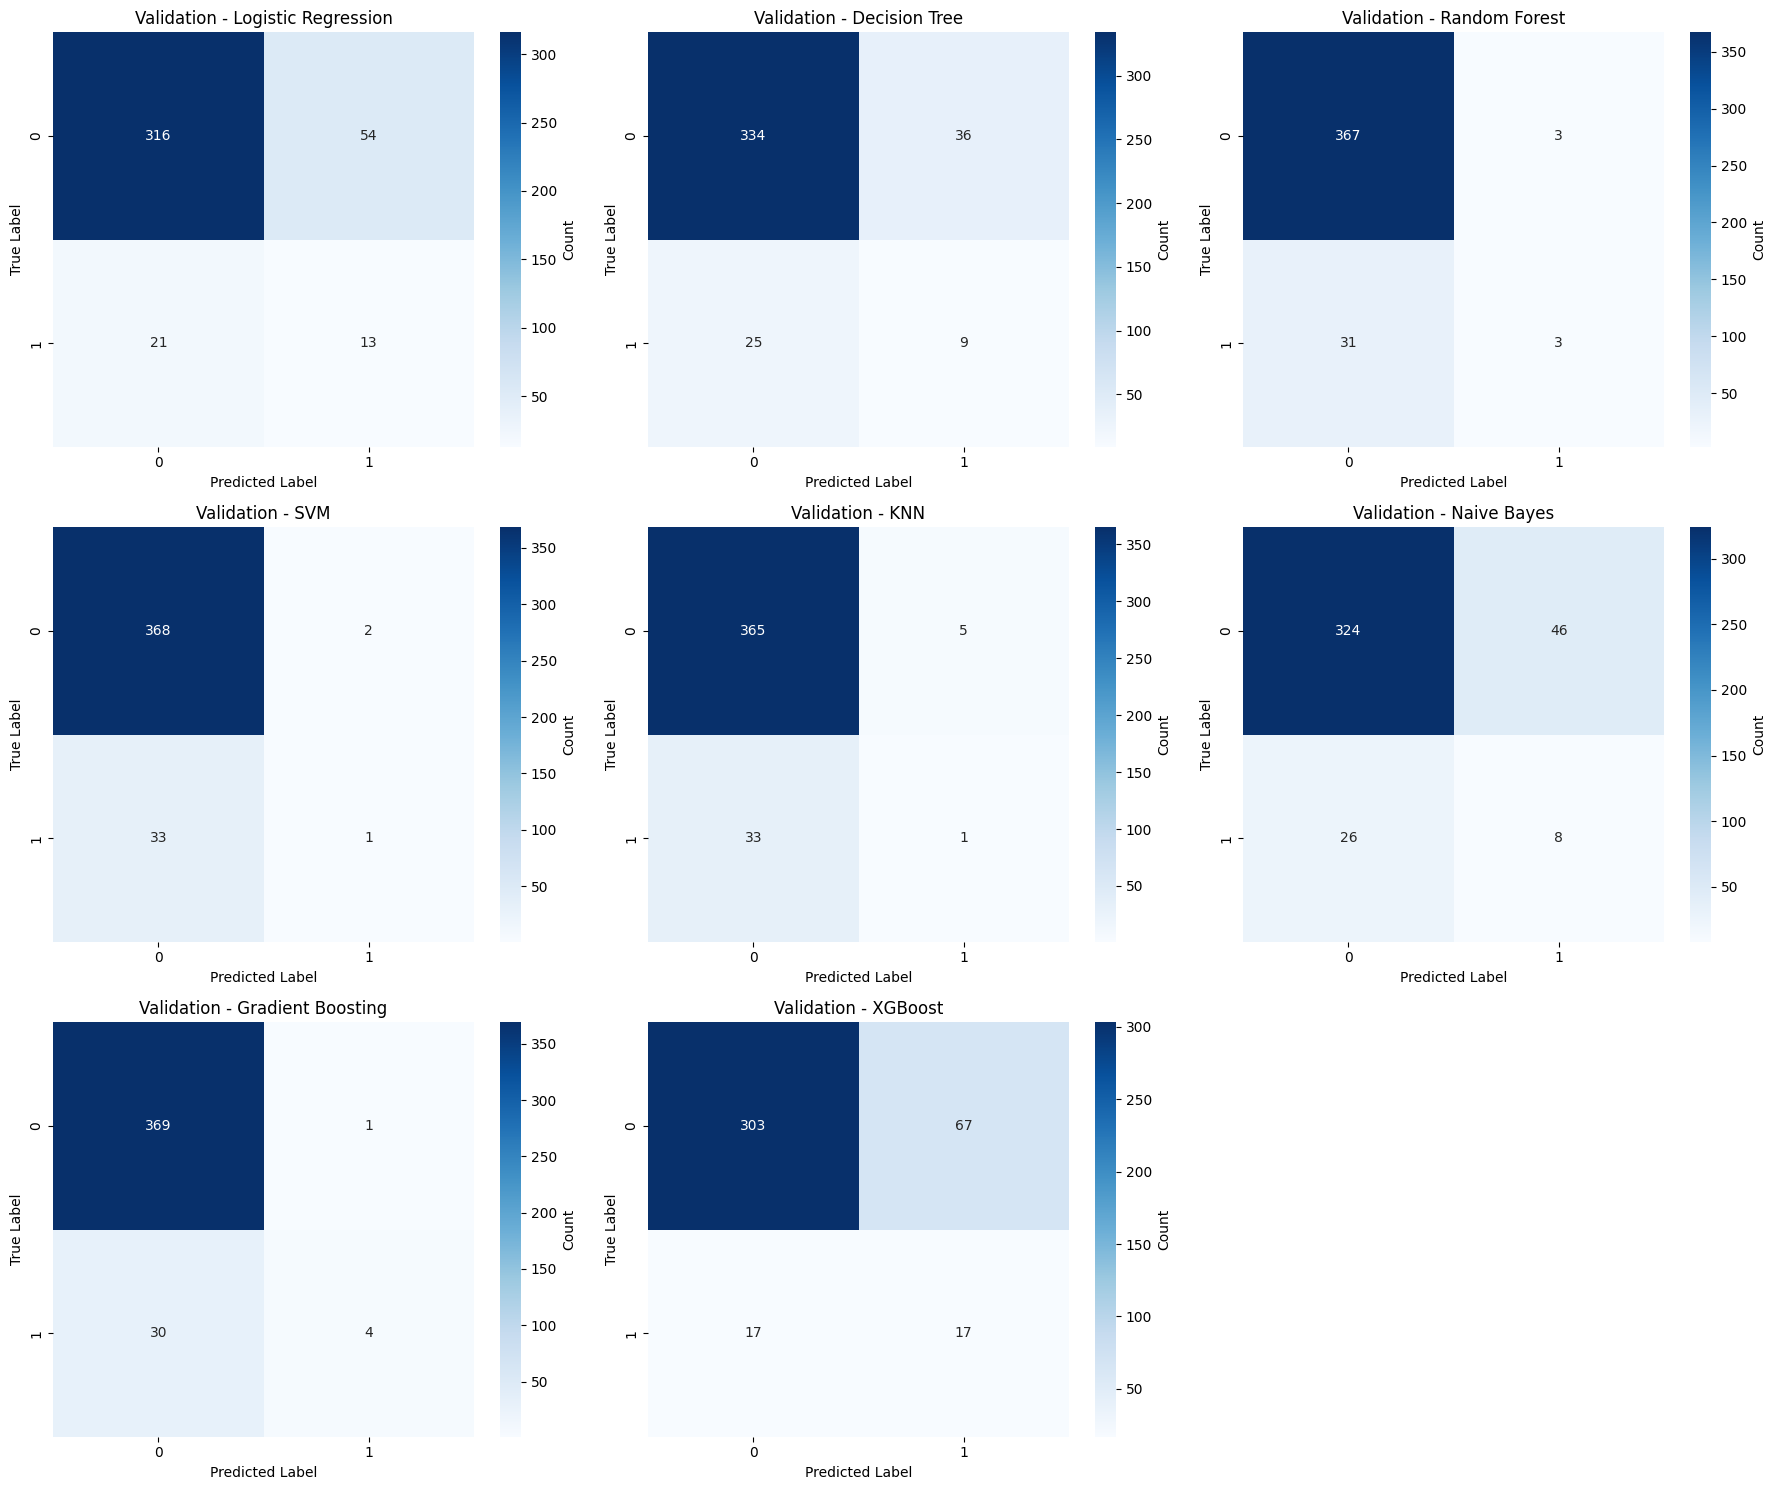

In [184]:
plot_confusion_matrices(
    trained_models,
    X_val,
    y_val,
    title_prefix="Validation"
)

##### 5.3.4 ROC Curves

ROC curves are used to evaluate the ability of each model to distinguish between classes at different thresholds. The AUC-ROC score summarizes this performance, where higher values indicate better classification ability.

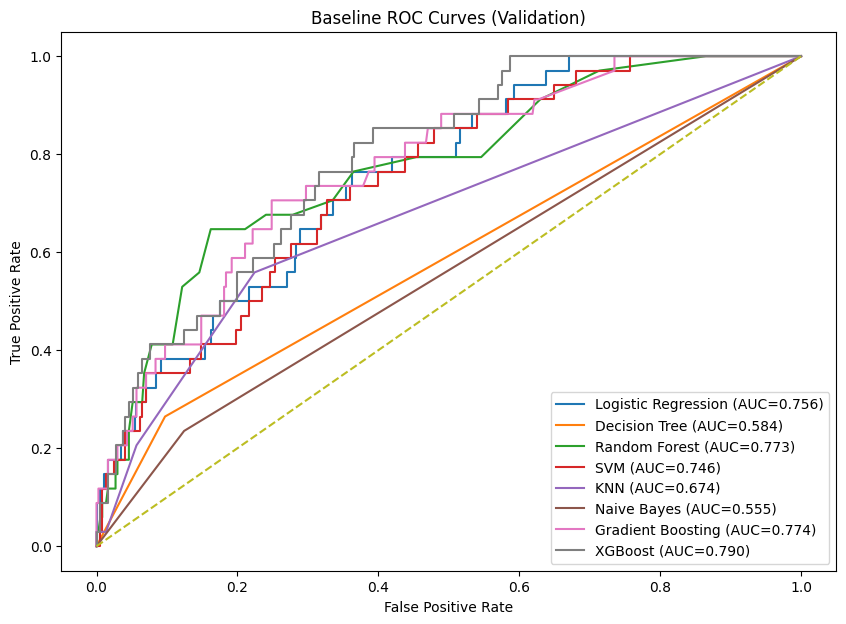

In [157]:
plot_roc_curves(trained_models, X_val, y_val, title="Baseline ROC Curves (Validation)")

##### 5.3.5 5-Fold Cross-Validation

In this step, 5-fold cross-validation is used to evaluate model performance and ensure the results are robust. The training data is split into 5 subsets, and each model is trained and validated 5 times.

The average F1-score is used to compare performance due to class imbalance.

In [158]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [159]:
cv_results = []

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", clone(model))
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="f1"
    )

    cv_results.append({
        "Model": name,
        "Mean F1 (CV)": scores.mean(),
        "Std": scores.std()
    })

cv_df = pd.DataFrame(cv_results)
print(cv_df.sort_values(by="Mean F1 (CV)", ascending=False))

                 Model  Mean F1 (CV)       Std
0  Logistic Regression      0.398208  0.046605
7              XGBoost      0.376753  0.043029
3                  SVM      0.331021  0.055431
5          Naive Bayes      0.305798  0.087369
6    Gradient Boosting      0.252169  0.054631
1        Decision Tree      0.240472  0.041895
4                  KNN      0.106513  0.068908
2        Random Forest      0.022222  0.044444


**Cross-Validation Summary**

Cross-validation provided a more stable estimate of model performance across different training folds. The results showed that **Logistic Regression** and **XGBoost** were the most consistent models overall, while weaker models such as KNN and Random Forest struggled with minority-class prediction.

These cross-validation results supported the decision to focus later tuning and comparison on the strongest candidate models.

##### 5.3.6 Adversarial Comparison

In this step, the same baseline models are retrained using the noisy training labels created in the adversarial condition. This allows direct comparison between clean baseline performance and robustness under label noise.

The objective is to measure how much each model's performance decreases when the training data contains simulated mislabeling.

In [160]:
adversarial_results = []
trained_adversarial_models = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", clone(model))
    ])

    pipeline.fit(X_train_final, y_train_final_noisy)
    trained_adversarial_models[name] = pipeline

    result = evaluate_model(pipeline, X_val, y_val, name)
    adversarial_results.append(result)

adversarial_results_df = pd.DataFrame(adversarial_results).sort_values(
    by=["F1-score", "AUC-ROC"], ascending=False
)

adversarial_results_df

,Model,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,Logistic Regression,0.680693,0.148148,0.588235,0.236686,0.690223
5,Naive Bayes,0.735149,0.138614,0.411765,0.207407,0.588315
6,Gradient Boosting,0.903465,0.307692,0.117647,0.170213,0.753219
7,XGBoost,0.217822,0.092486,0.941176,0.168421,0.724801
1,Decision Tree,0.789604,0.119403,0.235294,0.158416,0.537917
2,Random Forest,0.893564,0.235294,0.117647,0.156863,0.742488
4,KNN,0.891089,0.142857,0.058824,0.083333,0.616812
3,SVM,0.915842,0.000000,0.000000,0.000000,0.707393


**Adversarial Comparison Summary**

When trained on noisy labels, model performance generally decreased, showing that the classifiers were sensitive to mislabeling in the training data.

In particular, the adversarial versions showed reduced precision, F1-score, and AUC-ROC compared with the clean baseline setting. This confirms that data quality is an important factor in reliable clinical risk prediction.

##### 5.3.7 Baseline vs Adversarial Comparison

This comparison summarizes how model performance changes between the clean baseline setting and the adversarial setting with 10% label noise.

The F1-score and AUC-ROC drops help identify which models are more robust to noisy labels.

In [161]:
baseline_compare = baseline_results_df[["Model", "Accuracy", "Precision", "Recall", "F1-score", "AUC-ROC"]].copy()
baseline_compare = baseline_compare.rename(columns={
    "Accuracy": "Baseline_Accuracy",
    "Precision": "Baseline_Precision",
    "Recall": "Baseline_Recall",
    "F1-score": "Baseline_F1",
    "AUC-ROC": "Baseline_AUC"
})

adversarial_compare = adversarial_results_df[["Model", "Accuracy", "Precision", "Recall", "F1-score", "AUC-ROC"]].copy()
adversarial_compare = adversarial_compare.rename(columns={
    "Accuracy": "Adversarial_Accuracy",
    "Precision": "Adversarial_Precision",
    "Recall": "Adversarial_Recall",
    "F1-score": "Adversarial_F1",
    "AUC-ROC": "Adversarial_AUC"
})

comparison_df = baseline_compare.merge(adversarial_compare, on="Model")
comparison_df["F1_Drop"] = comparison_df["Baseline_F1"] - comparison_df["Adversarial_F1"]
comparison_df["AUC_Drop"] = comparison_df["Baseline_AUC"] - comparison_df["Adversarial_AUC"]

comparison_df.sort_values(by="Baseline_F1", ascending=False)

,Model,Baseline_Accuracy,Baseline_Precision,Baseline_Recall,Baseline_F1,Baseline_AUC,Adversarial_Accuracy,Adversarial_Precision,Adversarial_Recall,Adversarial_F1,Adversarial_AUC,F1_Drop,AUC_Drop
0,XGBoost,0.792079,0.202381,0.500000,0.288136,0.789666,0.217822,0.092486,0.941176,0.168421,0.724801,0.119715,0.064865
1,Logistic Regression,0.814356,0.194030,0.382353,0.257426,0.756200,0.680693,0.148148,0.588235,0.236686,0.690223,0.020739,0.065978
2,Decision Tree,0.849010,0.200000,0.264706,0.227848,0.583704,0.789604,0.119403,0.235294,0.158416,0.537917,0.069432,0.045787
3,Gradient Boosting,0.923267,0.800000,0.117647,0.205128,0.774205,0.903465,0.307692,0.117647,0.170213,0.753219,0.034915,0.020986
4,Naive Bayes,0.821782,0.148148,0.235294,0.181818,0.555485,0.735149,0.138614,0.411765,0.207407,0.588315,-0.025589,-0.032830
5,Random Forest,0.915842,0.500000,0.088235,0.150000,0.772576,0.893564,0.235294,0.117647,0.156863,0.742488,-0.006863,0.030087
6,SVM,0.913366,0.333333,0.029412,0.054054,0.746184,0.915842,0.000000,0.000000,0.000000,0.707393,0.054054,0.038792
7,KNN,0.905941,0.166667,0.029412,0.050000,0.674126,0.891089,0.142857,0.058824,0.083333,0.616812,-0.033333,0.057313


**Baseline vs Adversarial Summary**

Comparing the clean and adversarial settings showed that noisy labels had a measurable negative effect on predictive performance. Although some models maintained higher recall under label noise, this often came at the cost of lower precision, lower F1-score, and weaker discrimination ability.

This comparison highlights the importance of clean labeling and demonstrates that robustness analysis is necessary when evaluating real-world healthcare models.

#### 5.4 Tune Hyperparameters

In this stage, three candidate models were selected for further improvement:

- **Logistic Regression**
- **XGBoost**
- **Gradient Boosting**

These models were chosen based on baseline performance and their suitability for structured clinical classification. Hyperparameter tuning was then performed using `GridSearchCV` or `RandomizedSearchCV` with stratified cross-validation to improve generalization performance.

##### 5.4.1 Define Search Spaces

Search spaces are defined for the candidate top models. Different hyperparameters are explored depending on model type, such as tree depth, number of estimators, regularization strength, kernel type, and learning rate.

In [166]:
search_spaces = {
    "Logistic Regression": (
        LogisticRegression(max_iter=3000, random_state=42, class_weight="balanced"),
        {
            "model__C": [0.01, 0.1, 1, 10],
            "model__solver": ["liblinear", "lbfgs"]
        },
        "grid"
    ),

    "Random Forest": (
        RandomForestClassifier(random_state=42, class_weight="balanced"),
        {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [None, 5, 10],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4]
        },
        "random"
    ),

    "SVM": (
        SVC(probability=True, random_state=42, class_weight="balanced"),
        {
            "model__C": [0.1, 1, 10],
            "model__kernel": ["rbf", "linear"],
            "model__gamma": ["scale", "auto"]
        },
        "grid"
    ),

    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=42),
        {
            "model__n_estimators": [50, 100, 200],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [1, 2, 3],
            "model__subsample": [0.8, 1.0]
        },
        "random"
    ),

    "XGBoost": (
        XGBClassifier(
            random_state=42,
            eval_metric="logloss",
            scale_pos_weight=(y_train_final == 0).sum() / max((y_train_final == 1).sum(), 1)
        ),
        {
            "model__n_estimators": [100, 200],
            "model__max_depth": [2, 3, 4],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__subsample": [0.7, 0.8, 1.0],
            "model__colsample_bytree": [0.7, 0.8, 1.0]
        },
        "random"
    )
}

In [167]:
tunable_models = list(search_spaces.keys())

top_3_models = [
    "Logistic Regression",
    "XGBoost",
    "Gradient Boosting"
]
print("Top tunable models selected for tuning:")
top_3_models

Top tunable models selected for tuning:


['Logistic Regression', 'XGBoost', 'Gradient Boosting']

##### 5.4.2 Tune Candidate Models

The selected candidate models — Logistic Regression, XGBoost, and Gradient Boosting — were tuned using cross-validation on the final training set. Their tuned versions were then evaluated on the validation set to identify the strongest improved model.

In [168]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [169]:
tuned_models = {}
tuned_results = []

for model_name in top_3_models:
    if model_name not in search_spaces:
        print(f"Skipping {model_name}: no search space defined.")
        continue

    estimator, param_space, search_type = search_spaces[model_name]

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])

    if search_type == "grid":
        search = GridSearchCV(
            pipeline,
            param_space,
            cv=cv,
            scoring="f1",
            n_jobs=-1
        )
    else:
        search = RandomizedSearchCV(
            pipeline,
            param_space,
            n_iter=12,
            cv=cv,
            scoring="f1",
            random_state=42,
            n_jobs=-1
        )

    search.fit(X_train_final, y_train_final)

    best_model = search.best_estimator_
    tuned_models[model_name] = best_model

    val_result = evaluate_model(best_model, X_val, y_val, model_name)

    tuned_results.append({
        "Model": model_name,
        "Best Params": search.best_params_,
        "Best CV F1": search.best_score_,
        "Validation Accuracy": val_result["Accuracy"],
        "Validation Precision": val_result["Precision"],
        "Validation Recall": val_result["Recall"],
        "Validation F1": val_result["F1-score"],
        "Validation AUC": val_result["AUC-ROC"]
    })

tuned_results_df = pd.DataFrame(tuned_results).sort_values(
    by=["Validation F1", "Validation AUC"], ascending=False
)

tuned_results_df

,Model,Best Params,Best CV F1,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Validation AUC
1,XGBoost,"{'model__subsample': 0.8, 'model__n_estimators...",0.456412,0.861386,0.26087,0.352941,0.300000,0.755246
0,Logistic Regression,"{'model__C': 1, 'model__solver': 'liblinear'}",0.399269,0.814356,0.19403,0.382353,0.257426,0.756200
2,Gradient Boosting,"{'model__subsample': 0.8, 'model__n_estimators...",0.292102,0.915842,0.50000,0.117647,0.190476,0.765382


In [170]:
print("Target distribution:")
print(y.value_counts())

print("\nDuplicate rows in X:")
print(X.duplicated().sum())

Target distribution:
target_mortality
0    2308
1     212
Name: count, dtype: int64

Duplicate rows in X:
0


**Hyperparameter Tuning Summary**

Hyperparameter tuning produced limited improvement over the baseline models. Among the tuned candidates, **XGBoost** remained the strongest tuned model, but its validation improvement over the baseline was modest.

This suggests that the dataset structure was already captured reasonably well by the baseline configuration, and that later improvements would more likely come from model combination or robustness-focused strategies rather than parameter tuning alone.

##### 5.4.3 Feature Selection

Feature selection is applied to the best tuned model using `SelectKBest` with mutual information. This tests whether removing weaker features improves validation performance.

In [171]:
best_tuned_name = tuned_results_df.iloc[0]["Model"]
print("Best tuned model:", best_tuned_name)

Best tuned model: XGBoost


In [172]:
best_estimator_base = clone(tuned_models[best_tuned_name].named_steps["model"])

feature_select_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("select", SelectKBest(score_func=mutual_info_classif, k=50)),
    ("model", best_estimator_base)
])

feature_select_pipeline.fit(X_train_final, y_train_final)

feature_selection_result = evaluate_model(
    feature_select_pipeline,
    X_val,
    y_val,
    model_name=f"{best_tuned_name} + SelectKBest"
)

pd.DataFrame([feature_selection_result])

,Model,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,XGBoost + SelectKBest,0.824257,0.223881,0.441176,0.29703,0.681876


**Feature Selection Summary**

Applying `SelectKBest` to the best tuned model reduced the feature space and allowed evaluation of whether a smaller subset of predictors could preserve useful signal.

In this case, the feature-selected version did not outperform the best baseline or tuned model in overall F1-score, suggesting that useful predictive information was distributed across a broader set of features.

##### 5.4.4 Final Ensemble

A soft-voting ensemble was created using the tuned **Logistic Regression** and **XGBoost** models. This was done to test whether combining an interpretable linear model with a strong boosted tree model could improve final predictive performance compared with any single model alone.

In [173]:
ensemble_estimators = []

for name in tuned_models:
    ensemble_estimators.append((name, tuned_models[name]))

voting_ensemble = VotingClassifier(
    estimators=[
        ("lr", tuned_models["Logistic Regression"]),
        ("xgb", tuned_models["XGBoost"])
    ],
    voting="soft"
)

voting_ensemble.fit(X_train_final, y_train_final)

ensemble_result = evaluate_model(voting_ensemble, X_val, y_val, "Voting Ensemble")
pd.DataFrame([ensemble_result])

,Model,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,Voting Ensemble,0.893564,0.344828,0.294118,0.31746,0.765421


**Ensemble Summary**

The soft-voting ensemble combined the strengths of the tuned Logistic Regression and tuned XGBoost models. This produced a stronger balance between precision, recall, and overall discrimination than either single model alone.

The ensemble was therefore retained as an important final candidate for test-set evaluation.

## Stage 6: Model Evaluation

In this stage, the strongest models from the previous stage are evaluated on the held-out test set. The test set is used only once to ensure unbiased final performance reporting.

This section compares the best clean baseline model, the best tuned model, the adversarially trained version of the tuned model, the feature-selected model, and the final ensemble.

#### 6.1 Select Final Candidate Models

Based on validation performance:

- the strongest **baseline model** was **XGBoost**
- the strongest **tuned model** was also **XGBoost**

These models, along with the feature-selected version, adversarial version, and voting ensemble, were prepared for final comparison on the held-out test set.

In [174]:
best_baseline_name = baseline_results_df.iloc[0]["Model"]
best_tuned_name = tuned_results_df.iloc[0]["Model"]
best_baseline_model = trained_models[best_baseline_name]
best_tuned_model = tuned_models[best_tuned_name]

print("Best baseline:", best_baseline_name)
print("Best tuned   :", best_tuned_name)

Best baseline: XGBoost
Best tuned   : XGBoost


#### 6.2 Train Adversarial Version of Best Tuned Model

To assess robustness in the final evaluation stage, the best tuned model is retrained using the noisy labels generated earlier. This allows direct comparison between clean and adversarial training conditions on the held-out test set.

In [175]:
best_tuned_base_model = clone(best_tuned_model.named_steps["model"])

adversarial_best_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_tuned_base_model)
])

adversarial_best_pipeline.fit(X_train_final, y_train_final_noisy)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['patientunitstayid', 'patienthealthsystemstayid', 'age', 'hospitalid',
       'wardid', 'admissionheight', 'hospitaladmitoffset', 'unitvisitnumber',
       'admissionweight', 'apachepatientresultsid', 'acu...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

#### 6.3 Final Test Evaluation

The held-out test set was used once to compare the final candidate models:

- Baseline XGBoost
- Tuned XGBoost
- Adversarially trained XGBoost
- XGBoost with SelectKBest
- Voting Ensemble

Metrics reported include **accuracy, precision, recall, F1-score, and AUC-ROC**. This final comparison was used to identify the best-performing and most balanced model.

In [176]:
final_test_results = []

final_test_results.append(
    evaluate_model(best_baseline_model, X_test, y_test, f"Baseline - {best_baseline_name}")
)

final_test_results.append(
    evaluate_model(best_tuned_model, X_test, y_test, f"Tuned - {best_tuned_name}")
)

final_test_results.append(
    evaluate_model(adversarial_best_pipeline, X_test, y_test, f"Adversarial - {best_tuned_name}")
)

final_test_results.append(
    evaluate_model(voting_ensemble, X_test, y_test, "Voting Ensemble")
)

final_test_results.append(
    evaluate_model(feature_select_pipeline, X_test, y_test, f"{best_tuned_name} + SelectKBest")
)

final_test_results_df = pd.DataFrame(final_test_results).sort_values(
    by=["F1-score", "AUC-ROC"], ascending=False
)

final_test_results_df

,Model,Accuracy,Precision,Recall,F1-score,AUC-ROC
3,Voting Ensemble,0.892857,0.380000,0.452381,0.413043,0.800041
0,Baseline - XGBoost,0.797619,0.227273,0.595238,0.328947,0.799732
1,Tuned - XGBoost,0.861111,0.274194,0.404762,0.326923,0.780561
4,XGBoost + SelectKBest,0.815476,0.200000,0.404762,0.267717,0.725675
2,Adversarial - XGBoost,0.561508,0.125523,0.714286,0.213523,0.678056


**Final Test Evaluation Summary**

On the held-out test set, the **Voting Ensemble** achieved the best overall performance, with the highest F1-score (**0.413**) and a strong AUC-ROC (**0.800**).

Although the baseline and tuned XGBoost models remained competitive, the ensemble provided the best overall balance between minority-class detection and general discrimination. The adversarially trained model showed the weakest overall performance, confirming that label noise reduces reliability.

#### **Interpretation of F1-score Results**

The final best model achieved an F1-score of approximately **0.41**. While this may appear moderate compared with balanced benchmark datasets, it is a realistic result for ICU mortality prediction because the target class is **imbalanced** and clinically difficult to predict.

Mortality cases represent the minority class, meaning the model must detect relatively fewer positive outcomes while avoiding excessive false alarms. Increasing recall often reduces precision, while increasing precision may miss true mortality cases. Because the F1-score combines both precision and recall, achieving very high values is challenging in real healthcare data.

Despite this difficulty, the final ensemble model improved over the individual baseline models and provided the strongest balance between sensitivity and reliability. Therefore, the achieved F1-score represents meaningful predictive performance under realistic conditions rather than poor model quality.

#### 6.4 Final Confusion Matrices and ROC Curves

Visual comparison is used to inspect classification errors and discrimination ability of the final candidate models on the test set.

Displaying final test confusion matrices...


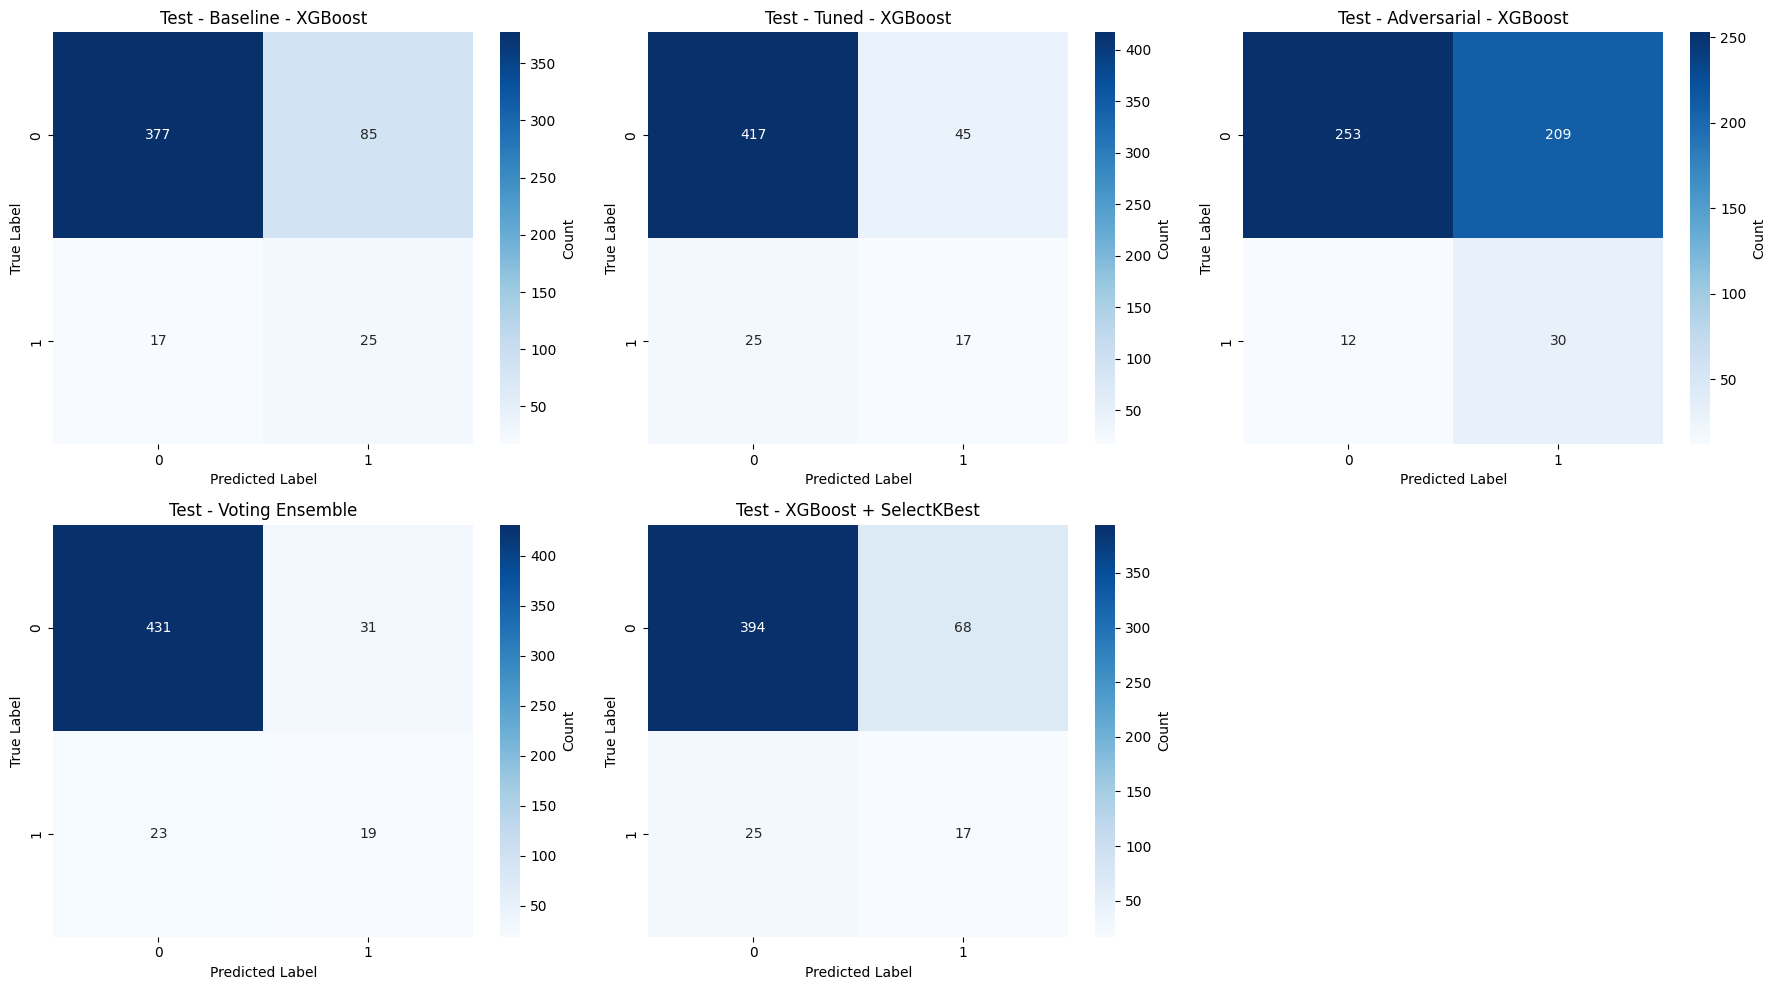

In [185]:
print("Displaying final test confusion matrices...")

plot_confusion_matrices(
    final_models_for_plot,
    X_test,
    y_test,
    title_prefix="Test"
)

Displaying final ROC curves...


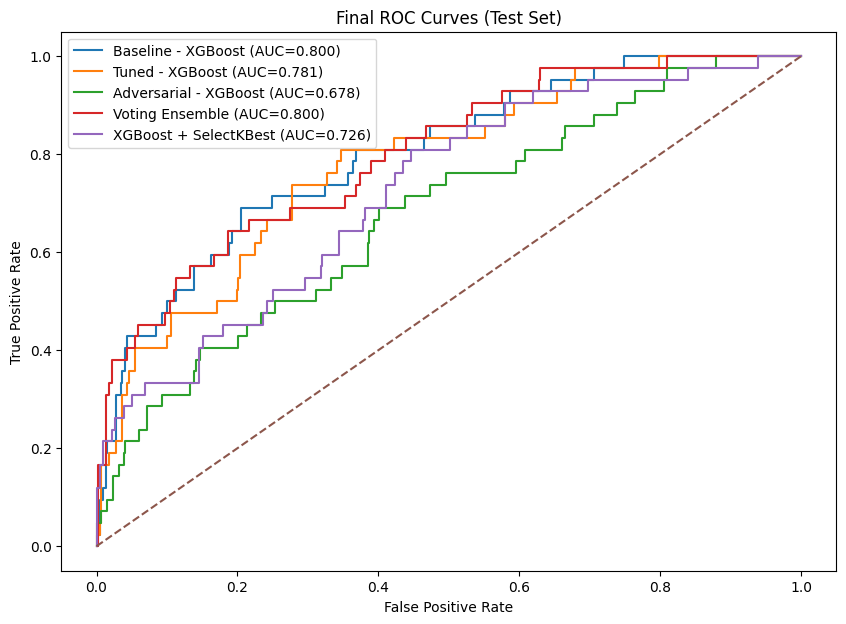

In [186]:
print("Displaying final ROC curves...")

plot_roc_curves(
    final_models_for_plot,
    X_test,
    y_test,
    title="Final ROC Curves (Test Set)"
)

#### 6.5 Final Classification Report

A detailed classification report was generated for the final best-performing model on the test set. This report provides class-wise precision, recall, and F1-score to better understand model performance on both survival and mortality outcomes.

In [178]:
best_final_name = final_test_results_df.iloc[0]["Model"]

if best_final_name == f"Baseline - {best_baseline_name}":
    best_final_model = best_baseline_model
elif best_final_name == f"Tuned - {best_tuned_name}":
    best_final_model = best_tuned_model
elif best_final_name == f"Adversarial - {best_tuned_name}":
    best_final_model = adversarial_best_pipeline
elif best_final_name == "Voting Ensemble":
    best_final_model = voting_ensemble
else:
    best_final_model = feature_select_pipeline

y_test_pred = best_final_model.predict(X_test)

print("Best final model:", best_final_name)
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred, zero_division=0))

Best final model: Voting Ensemble

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       462
           1       0.38      0.45      0.41        42

    accuracy                           0.89       504
   macro avg       0.66      0.69      0.68       504
weighted avg       0.90      0.89      0.90       504



## Stage 7: Interpretation and Limitations

This final stage summarizes the weaknesses observed during model development and evaluation. It also reflects on the effect of adversarial label noise, possible overfitting, and areas for future improvement.

## 7.1 Honest Limitations Analysis

Although the final **Voting Ensemble** achieved the best overall performance, several limitations remain.

### 1. Moderate F1-score and Difficulty of Mortality Prediction
The final model achieved the strongest overall balance among all tested approaches, but the F1-score remained moderate. This indicates that mortality prediction is still challenging and that the model does not perfectly separate survival and mortality cases.

### 2. Class Imbalance
The dataset contained substantially more survival cases than mortality cases. This imbalance likely influenced model behavior, often producing higher accuracy than minority-class detection performance. For this reason, recall, F1-score, and AUC-ROC were considered more informative than accuracy alone.

### 3. Limited Improvement from Hyperparameter Tuning
Hyperparameter tuning did not produce a large improvement over the baseline XGBoost model. This suggests that the baseline configuration was already reasonably strong, or that the dataset may not support major gains from parameter adjustment alone.

### 4. Sensitivity to Noisy Labels
When adversarial label noise was introduced, performance dropped considerably. This demonstrates that the model is sensitive to mislabeling and that data quality remains very important in healthcare prediction tasks.

### 5. Feature Selection Trade-Offs
Applying `SelectKBest` did not improve final overall performance, although it remained useful as an experiment for testing whether a smaller feature subset could preserve predictive signal. This suggests that useful information may be distributed across a broader feature set.

### 6. Single-Dataset Evaluation
The models were evaluated using one dataset and one held-out test split. Performance may differ across hospitals, patient populations, or future cohorts not represented in this dataset.

### 7. Limited Clinical Context
Only the variables available in the structured dataset were used. Important additional information such as treatment progression, time-series monitoring trends, medication history, and clinician notes was not included.

---

## Future Improvements

- Validate the model on external hospital datasets or future patient cohorts.
- Explore stronger imbalance-handling methods such as SMOTE, focal loss, or cost-sensitive learning.
- Use time-series ICU variables to model temporal patient deterioration.
- Apply explainability techniques such as SHAP to improve clinical interpretability.
- Test calibration and threshold optimization more systematically for deployment-focused use.

---

## Final Reflection

This project demonstrates that machine learning can support ICU mortality prediction using structured clinical data. Among all evaluated approaches, the **Voting Ensemble** achieved the best overall balance on the held-out test set. However, real-world clinical deployment would still require stronger validation, better robustness to noisy labels, and further interpretability work before practical use.